### **Configuración Inicial**

Este bloque importa las librerías necesarias para el análisis de datos. Se incluyen:

*   **`pandas`**: Para manipulación y análisis de datos.
*   **`numpy`**: Para operaciones numéricas, especialmente con arrays.
*   **`matplotlib.pyplot`**: Para la creación de gráficos estáticos.
*   **`seaborn`**: Para visualizaciones estadísticas atractivas.
*   **`sklearn.preprocessing.StandardScaler`**: Para normalizar características (escalado de datos).
*   **`sklearn.preprocessing.LabelEncoder`**: Para codificar variables categóricas a numéricas.
*   **`sklearn.cluster.DBSCAN`**: Para la detección de anomalías y agrupación de datos.
*   **`sklearn.model_selection.train_test_split`**: Para dividir datos en conjuntos de entrenamiento y prueba (aunque no se usa en este notebook específico).
*   **`sklearn.decomposition.PCA`**: Para reducción de dimensionalidad (aunque no se usa en este notebook específico).
*   **`warnings`**: Para suprimir advertencias durante la ejecución del código.

In [3]:
!pip install seaborn scikit-learn pandas numpy matplotlib plotly -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

### **Carga de Datos**

En este bloque, se carga el dataset directamente desde una hoja de cálculo de Google Sheets, la cual se exporta en formato CSV. Los pasos son:

1.  **Importar `pandas`**: Se asegura que la librería `pandas` esté disponible para leer el archivo CSV.
2.  **Definir `url`**: Se establece la URL pública del archivo CSV alojado en Google Sheets.
3.  **Cargar `df`**: Se utiliza `pd.read_csv()` para leer los datos desde la URL y guardarlos en un DataFrame llamado `df`.
4.  **Imprimir resumen**: Se muestra la cantidad de filas y columnas del DataFrame cargado, junto con las primeras 5 filas (`df.head()`), para verificar que la carga se realizó correctamente.

In [5]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1CNn3BdYl7oUASLtjX5KR52PKjxSQmtpK/export?format=csv"

df = pd.read_csv(url)

print(" DATOS CARGADOS:")
print(f"Filas: {len(df)}")
print(f"Columnas: {len(df.columns)}")
print("\n")
print(df.head())

 DATOS CARGADOS:
Filas: 2115
Columnas: 12


       dip     Género Fecha de Nacimiento            Zona       Av. o Calle  \
0   260910  Masculino          2010-01-01               0                 0   
1   487541  Masculino          1994-04-01  VILLA VICTORIA         REPUBLICA   
2   748784  Masculino          1991-12-15     16 DE JULIO  VICTOR GUTIERREZ   
3  1763419  Masculino          1974-03-26          CALUYO         CALLE "6"   
4  2140504  Masculino          2010-01-01               0                 0   

  Nro Casa     País Departamento Provincia  Ciudad  \
0        0  BOLIVIA       LA PAZ         0       0   
1     1967  BOLIVIA       LA PAZ   MURILLO  LA PAZ   
2     3346  BOLIVIA       LA PAZ   MURILLO  LA PAZ   
3      528  BOLIVIA       LA PAZ   MURILLO  LA PAZ   
4        0  BOLIVIA       LA PAZ         0       0   

                                            Colegio Administración del Colegio  
0                                                 0                     FIS

### **: Inspección Inicial de Datos Faltantes**

Este bloque tiene como objetivo principal identificar y mostrar la cantidad de valores faltantes (NaN o `None`) en cada columna del DataFrame `df` después de la carga inicial. Los pasos son:

1.  **`df.isnull().sum()`**: Calcula la suma de valores nulos para cada columna.
2.  **Filtrar columnas con faltantes**: Muestra solo aquellas columnas que tienen al menos un valor faltante (`faltantes > 0`).
3.  **Total de faltantes**: Calcula e imprime el número total de valores faltantes en todo el DataFrame (`df.isnull().sum().sum()`).

Este paso es crucial para entender la calidad y completitud del dataset antes de proceder con cualquier proceso de limpieza o imputación.

In [6]:
print(" DATOS FALTANTES:\n")
faltantes = df.isnull().sum()
print(faltantes[faltantes > 0])
print(f"\nTotal faltantes: {df.isnull().sum().sum()}")


 DATOS FALTANTES:

Fecha de Nacimiento             1
Zona                          217
Av. o Calle                   231
Nro Casa                      271
País                            1
Departamento                    4
Provincia                     213
Ciudad                        243
Colegio                       215
Administración del Colegio     24
dtype: int64

Total faltantes: 1420


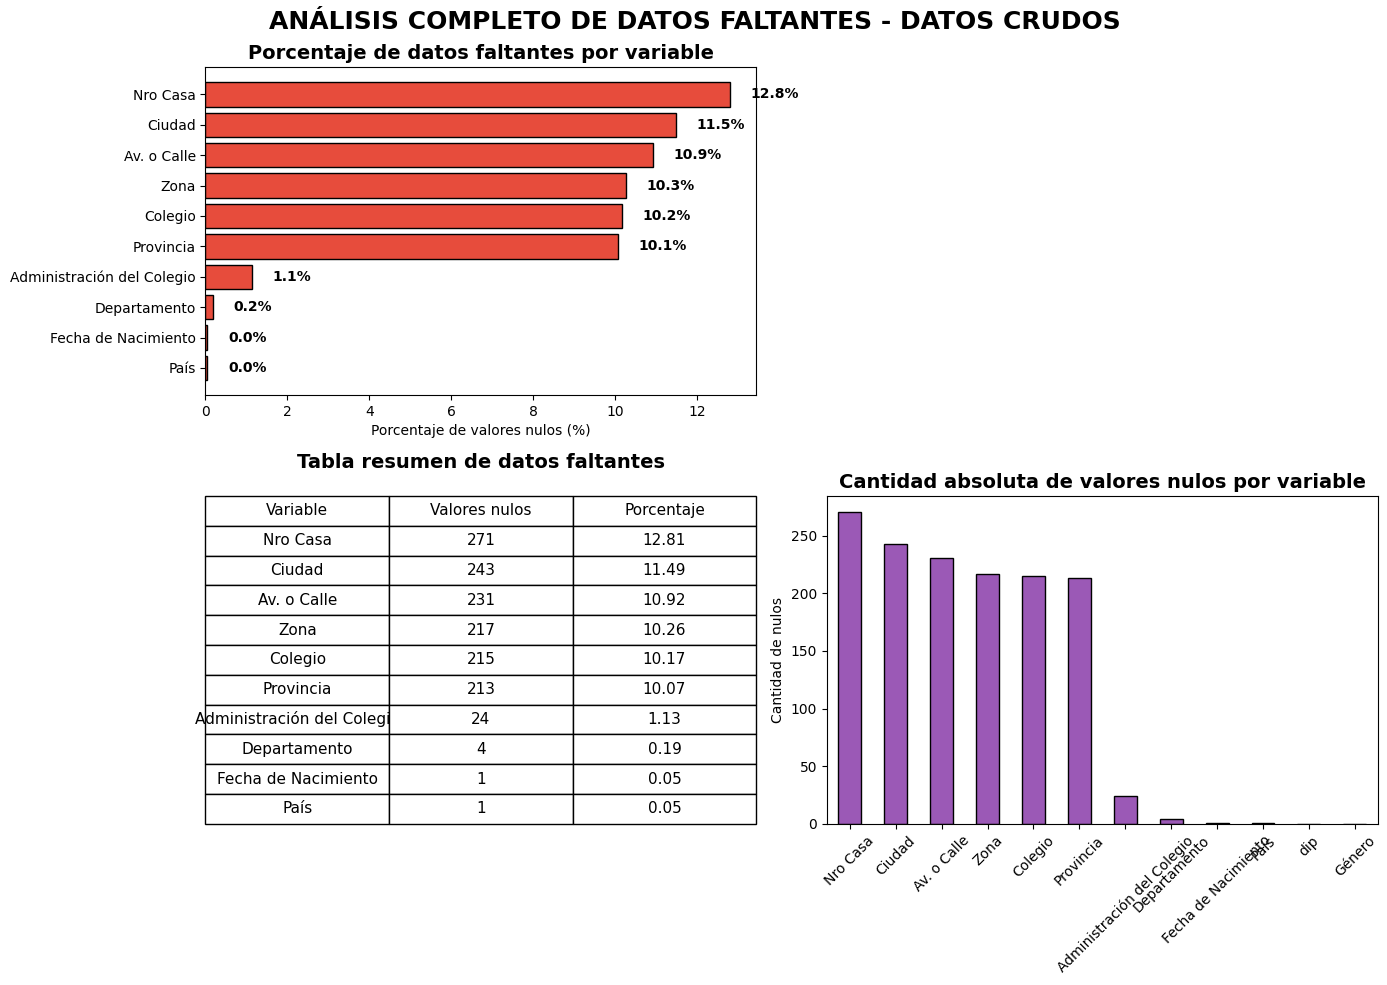

RESUMEN DE DATOS FALTANTES
Total de celdas: 25,380
Celdas con datos faltantes: 1,420
Porcentaje total de datos faltantes: 5.59%

Variables con más datos faltantes:
Nro Casa                      12.813239
Ciudad                        11.489362
Av. o Calle                   10.921986
Zona                          10.260047
Colegio                       10.165485
Provincia                     10.070922
Administración del Colegio     1.134752
Departamento                   0.189125
Fecha de Nacimiento            0.047281
País                           0.047281
dtype: float64


In [7]:
# ===================================================================
# 4. ANÁLISIS DE DATOS FALTANTES (MISSING VALUES) - VERSIÓN PRO 2025
# ===================================================================

fig = plt.figure(figsize=(14, 10))


# 2. Barras horizontales con % de nulos por columna
plt.subplot(2, 2, 1)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]  # solo las que tienen nulos

bars = plt.barh(missing_percent.index, missing_percent.values, color='#e74c3c', edgecolor='black')
plt.title('Porcentaje de datos faltantes por variable', fontweight='bold', fontsize=14)
plt.xlabel('Porcentaje de valores nulos (%)')
plt.gca().invert_yaxis()

# Añadimos el % encima de cada barra
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontweight='bold')

# 3. Tabla resumen (opcional pero queda brutal)
plt.subplot(2, 2, 3)
missing_table = pd.DataFrame({
    'Variable': missing_percent.index,
    'Valores nulos': df.isnull().sum()[missing_percent.index],
    'Porcentaje': missing_percent.values.round(2)
})
plt.axis('tight')
plt.axis('off')
tabla = plt.table(cellText=missing_table.values,
                  colLabels=missing_table.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 2)
plt.title('Tabla resumen de datos faltantes', fontweight='bold', fontsize=14, pad=20)

# 4. Gráfico de barras vertical simple (clásico)
plt.subplot(2, 2, 4)
df.isnull().sum().sort_values(ascending=False).plot(kind='bar', color='#9b59b6', edgecolor='black')
plt.title('Cantidad absoluta de valores nulos por variable', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de nulos')
plt.xticks(rotation=45)

plt.suptitle('ANÁLISIS COMPLETO DE DATOS FALTANTES - DATOS CRUDOS',
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Resumen rápido en texto
print("RESUMEN DE DATOS FALTANTES")
print(f"Total de celdas: {df.shape[0] * df.shape[1]:,}")
print(f"Celdas con datos faltantes: {df.isnull().sum().sum():,}")
print(f"Porcentaje total de datos faltantes: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
print("\nVariables con más datos faltantes:")
print(missing_percent.head(10))

### ** Eliminación de Duplicados (Primera Pasada)**

Este bloque se encarga de identificar y eliminar las filas duplicadas en el DataFrame `df`. La eliminación de duplicados es un paso importante en la limpieza de datos para evitar que registros idénticos sesguen el análisis. Los pasos son:

1.  **Contar duplicados antes**: Se calcula el número de filas duplicadas antes de la eliminación usando `df.duplicated().sum()`.
2.  **Eliminar duplicados**: Se eliminan las filas duplicadas con `df.drop_duplicates()`, conservando la primera ocurrencia por defecto.
3.  **Contar duplicados después**: Se verifica que no queden duplicados después de la operación.
4.  **Informar cambios**: Se imprime el número de duplicados encontrados y eliminados, así como el número de filas restantes en el DataFrame.

In [8]:
# Cantidad total de valores duplicados en la columna dip
duplicados_dip = df['dip'].duplicated().sum()
print(f"Cantidad de duplicados en dip: {duplicados_dip}")

# Ver cuáles son los valores duplicados y cuántas veces se repiten
conteo_dip = df['dip'].value_counts()
dip_duplicados_detalle = conteo_dip[conteo_dip > 1]

print("\nValores de dip que están duplicados:")
print(dip_duplicados_detalle)

Cantidad de duplicados en dip: 127

Valores de dip que están duplicados:
dip
5999667    3
6166808    3
4911025    3
6735664    2
6765722    2
          ..
4925884    2
4939172    2
6843687    2
4055780    2
6074664    2
Name: count, Length: 124, dtype: int64


In [9]:
# Identificar valores duplicados en la columna dip
duplicados = df[df['dip'].duplicated(keep=False)]

# Mostrar todas las filas duplicadas
print("FILAS DUPLICADAS EN LA VARIABLE 'dip':\n")
duplicados
# Paso 1: Identificar solo los dip duplicados
dips_duplicados = df['dip'][df['dip'].duplicated(keep=False)]

FILAS DUPLICADAS EN LA VARIABLE 'dip':



In [10]:
# ===================================================================
# TRATAMIENTO DE DIP DUPLICADOS - VERSIÓN SIMPLE Y QUE SÍ FUNCIONA
# ===================================================================

print(f"Filas antes de limpiar DIP: {len(df)}")

# 1. Ver cuántos DIP están duplicados
print(f"DIP duplicados: {df['dip'].duplicated().sum()}")

# 2. Crear una columna temporal con cuántos datos NO nulos tiene cada fila
df['datos_completos'] = df.notnull().sum(axis=1)

# 3. PRIORIZAR: si una fila tiene género real → gana aunque tenga menos datos
# (esto soluciona el problema de "NO RESPONDE")
df['tiene_genero_real'] = df['Género'].isin(['Masculino', 'Femenino'])

# Si tiene género real → le damos 1000 puntos extra (así siempre gana)
df['puntuacion'] = df['datos_completos']
df.loc[df['tiene_genero_real'], 'puntuacion'] += 1000

# 4. Ordenar: mismo DIP → la que tenga mayor puntuación primero
df = df.sort_values(['dip', 'puntuacion'], ascending=[True, False])

# 5. Eliminar duplicados → se queda con la mejor fila
df = df.drop_duplicates(subset='dip', keep='first')

# 6. Borrar columnas temporales
df = df.drop(columns=['datos_completos', 'tiene_genero_real', 'puntuacion'])

print(f"Filas después de limpiar DIP: {len(df)}")
print("¡Listo! Ahora cada estudiante tiene un DIP único y el género correcto cuando existe")

Filas antes de limpiar DIP: 2115
DIP duplicados: 127
Filas después de limpiar DIP: 1988
¡Listo! Ahora cada estudiante tiene un DIP único y el género correcto cuando existe


In [11]:


# Filtrar solo esas filas duplicadas
df_dup = df[df['dip'].isin(dips_duplicados)]

# Paso 2: Contar datos no nulos por fila
df_dup['non_null_count'] = df_dup.notnull().sum(axis=1)

# Paso 3: Ordenar para que la fila más completa quede primera
df_dup_sorted = df_dup.sort_values(by=['dip', 'non_null_count'], ascending=[True, False])

# Paso 4: Quedarnos SOLO con la fila más completa de cada dip
df_dup_final = df_dup_sorted.drop_duplicates(subset='dip', keep='first')

# Mostrar resultado
df_dup_final

,dip,Género,Fecha de Nacimiento,Zona,Av. o Calle,Nro Casa,País,Departamento,Provincia,Ciudad,Colegio,Administración del Colegio,non_null_count
59,4055780,Femenino,1992-01-26,Chuquiaguillo,Luis Espinal,NaN,BOLIVIA,ORURO,Cercado,NaN,Colegio Boliviano Aleman Ave Maria,PRIVADA,10
79,4269638,Masculino,1990-06-19,san sebastian,av montes esq pucarani,90,BOLIVIA,LA PAZ,murillo,la paz,don bosco,PRIVADA,12
98,4299485,Femenino,1990-12-17,"Sopocachi, Cristo Rey","Calle Carlos Medinacelli, Rot. Invalidos Del C...",1033,BOLIVIA,LA PAZ,Murillo,La Paz,Boliviano Japones,PRIVADA,12
111,4311398,Masculino,1991-07-20,Obrajes,Calle 4,368,BOLIVIA,LA PAZ,Murillo,La Paz,Instituto Americano,PRIVADA,12
128,4322570,Masculino,1990-12-01,NaN,NaN,NaN,BOLIVIA,LA PAZ,NaN,NaN,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1954,6815511,Femenino,1940-01-01,NaN,NaN,NaN,BOLIVIA,LA PAZ,NaN,NaN,NaN,FISCAL,6
1979,6823974,Masculino,1988-02-22,VILLA EXALTACION,CALLE 1,16,BOLIVIA,POTOSÍ,ANTONIO QUIJARRO,UYUNI,INST. TEC. PUERTO DE MEJILLLONES,FISCAL,12
2036,6835533,Masculino,1988-08-03,Pura Pura,Av. Ismael Vasquez,1396,BOLIVIA,LA PAZ,Murillo,La paz,Centro Educativo,PRIVADA,12
2050,6837928,Femenino,1987-06-23,La Merced,NaN,1834,BOLIVIA,LA PAZ,Murillo,LA PAZ,Instituto TÃÂ©cnico Ayacucho,FISCAL,11


In [12]:
duplicados_antes = df.duplicated().sum()
df = df.drop_duplicates()
duplicados_despues = df.duplicated().sum()

print(f" DUPLICADOS REMOVIDOS:")
print(f"Antes: {duplicados_antes}")
print(f"Después: {duplicados_despues}")
print(f"Filas ahora: {len(df)}")

 DUPLICADOS REMOVIDOS:
Antes: 0
Después: 0
Filas ahora: 1988


### **: Limpieza Inicial y Conversión de Fecha**

Este bloque realiza dos tareas clave de limpieza y preprocesamiento:

1.  **Eliminación de duplicados (confirmación)**: Aunque ya se hizo una pasada inicial, este paso asegura que no haya duplicados residuales. `df.drop_duplicates()` se aplica nuevamente.
2.  **Conversión de 'Fecha de Nacimiento'**: La columna `Fecha de Nacimiento` se convierte al tipo de dato `datetime` de pandas. Esto es fundamental para trabajar con fechas (extraer el año, calcular edades, etc.).
    *   `pd.to_datetime(errors='coerce')` intenta la conversión, y si encuentra un valor que no puede convertir a fecha, lo reemplaza con `NaT` (Not a Time), lo que permite continuar el procesamiento sin errores y facilita la identificación de fechas inválidas.

In [13]:
# LIMPIEZA INICIAL
print("\n" + "="*80)
print(" LIMPIEZA INICIAL")
print("="*80)


#  CONVERTIR FECHA DE NACIMIENTO
print(f"\n CONVIRTIENDO FECHA DE NACIMIENTO...")
if 'Fecha de Nacimiento' in df.columns:
    df['Fecha de Nacimiento'] = pd.to_datetime(df['Fecha de Nacimiento'], errors='coerce')
    print(f"   Fechas convertidas al formato datetime")
    print(f"   • Valores válidos: {df['Fecha de Nacimiento'].notna().sum()}")
    print(f"   • Valores inválidos (NaT): {df['Fecha de Nacimiento'].isna().sum()}")

print(f"\n LIMPIEZA INICIAL COMPLETADA")



 LIMPIEZA INICIAL

 CONVIRTIENDO FECHA DE NACIMIENTO...
   Fechas convertidas al formato datetime
   • Valores válidos: 1987
   • Valores inválidos (NaT): 1

 LIMPIEZA INICIAL COMPLETADA


### **Estandarización de Texto**

Este bloque se dedica a limpiar y estandarizar  y corregir los errores tipograficos el formato de las columnas de texto en el DataFrame, lo cual es fundamental para asegurar la consistencia y evitar errores en análisis posteriores (como agrupaciones o conteos de valores únicos).

1.  **Función `estandarizar_texto`**: Define una función que realiza las siguientes operaciones en una cadena de texto:
    *   `strip()`: Elimina espacios en blanco al inicio y al final.
    *   `upper()`: Convierte todo el texto a mayúsculas para unificar

In [14]:
import unicodedata

# ESTANDARIZACIÓN DE TEXTO
print("\n" + "="*80)
print(" ESTANDARIZACIÓN DE TEXTO")
print("="*80)

def estandarizar_texto(texto):
    if isinstance(texto, str):
        # Eliminar espacios al inicio y final, convertir a mayúsculas
        texto = texto.strip().upper()
        # Normalizar acentos (NFD = descomponer)
        texto = unicodedata.normalize('NFD', texto)
        # Eliminar marcas diacríticas (acentos)
        texto = ''.join(c for c in texto if not unicodedata.combining(c))
        return texto
    return texto

# Columnas a estandarizar
columnas_categoricas = [
    'Género', 'Zona', 'Av. o Calle', 'País', 'Departamento',
    'Provincia', 'Ciudad', 'Colegio', 'Administración del Colegio'
]

print(f"\n Estandarizando {len(columnas_categoricas)} columnas...")
for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].apply(estandarizar_texto)
        print(f"    {col}")

print(f"\n ESTANDARIZACIÓN COMPLETADA")


 ESTANDARIZACIÓN DE TEXTO

 Estandarizando 9 columnas...
    Género
    Zona
    Av. o Calle
    País
    Departamento
    Provincia
    Ciudad
    Colegio
    Administración del Colegio

 ESTANDARIZACIÓN COMPLETADA


### **Limpieza de Campos Especiales (Nro Casa)**

Este bloque se enfoca en la limpieza específica de la columna `Nro Casa`.

**Propósito:**
*   **Unificación y Normalización**: Los números de casa a menudo contienen caracteres especiales (#, -, espacios extra) o valores inconsistentes (0, S/N, NaN). Esta limpieza unifica estos formatos para facilitar su uso posterior.
*   **Manejo de Faltantes**: Los valores nulos o

In [15]:
# LIMPIEZA DE CAMPOS ESPECIALES
print("\n" + "="*80)
print("BLOQUE: LIMPIEZA DE CAMPOS ESPECIALES")
print("="*80)

# FUNCIÓN PARA LIMPIAR NRO CASA
def limpiar_nro_casa(valor):
    """
    Limpia números de casa: elimina caracteres especiales (#, -),
    convierte a mayúsculas, y reemplaza NaN por "S/N"
    """
    if pd.isna(valor):
        return "S/N"
    valor = str(valor).strip().upper()
    valor = valor.replace("#", "").replace("-", "").replace(".", "")
    return valor if valor else "S/N"

if "Nro Casa" in df.columns:
    df["Nro Casa"] = df["Nro Casa"].apply(limpiar_nro_casa)
    print(f"   NRO CASA limpiado")

print(f"\n LIMPIEZA DE CAMPOS ESPECIALES COMPLETADA")



BLOQUE: LIMPIEZA DE CAMPOS ESPECIALES
   NRO CASA limpiado

 LIMPIEZA DE CAMPOS ESPECIALES COMPLETADA


### **FUNCIÓN DE IMPUTACIÓN JERÁRQUICA**

Este bloque define la función `imputar_jerarquia`, una herramienta fundamental para rellenar valores faltantes en el DataFrame de una manera inteligente y contextual. Su propósito es mantener la coherencia geográfica o contextual de los datos al imputar.

**Lógica de Funcionamiento:**
1.  **Agrupación Jerárquica**: La función agrupa los registros del DataFrame basándose en una jerarquía predefinida (por ejemplo, País → Departamento → Provincia → Ciudad).
2.  **Cálculo de la Moda Local**: Dentro de cada uno de estos grupos, se calcula la moda (el valor más frecuente) de la columna que se desea imputar.
3.  **Relleno de `NaN`**: Los valores `NaN` (Not a Number) dentro de cada grupo se rellenan con la moda calculada para ese grupo específico.
4.  **Valores sin Moda**: Si un grupo particular no tiene una moda definida (por ejemplo, todos los valores son `NaN` o no hay un valor predominante), los valores faltantes se imputan con la cadena 'DESCONOCIDO'.

**Ventajas Clave:**
*   **Preserva Coherencia**: A diferencia de una imputación global (usando la moda de todo el dataset), esta función asegura que los valores imputados sean relevantes para la región o contexto al que pertenecen.
*   **Ejemplo Práctico**: Los registros de una ciudad específica se imputarán con los valores más comunes de esa misma ciudad, y no con los valores más comunes de todo el país.

La función es genérica y puede aplicarse a cualquier columna categórica donde tenga sentido una imputación basada en la proximidad o la jerarquía.

In [16]:
# FUNCIÓN DE IMPUTACIÓN JERÁRQUICA
print("\n" + "="*80)
print(" FUNCIÓN DE IMPUTACIÓN JERÁRQUICA")
print("="*80)

def imputar_jerarquia(df, col, jerarquia):
    def rellenar_grupo(grupo):
        modos = grupo[col].mode()
        if not modos.empty:
            return grupo[col].fillna(modos.iloc[0])
        else:
            return grupo[col].fillna('DESCONOCIDO')

    return df.groupby(jerarquia, dropna=False, as_index=False).apply(rellenar_grupo).droplevel(0)

print(" FUNCIÓN IMPUTACIÓN JERÁRQUICA CARGADA")
print("\nEsta función preserva coherencia contextual mediante:")
print("   • Agrupación por jerarquía geográfica")
print("   • Uso de MODA LOCAL (no global)")
print("   • Conservación de registros completos")



 FUNCIÓN DE IMPUTACIÓN JERÁRQUICA
 FUNCIÓN IMPUTACIÓN JERÁRQUICA CARGADA

Esta función preserva coherencia contextual mediante:
   • Agrupación por jerarquía geográfica
   • Uso de MODA LOCAL (no global)
   • Conservación de registros completos


### **Eliminación de Filas con Exceso de Faltantes**

Este bloque tiene como objetivo identificar y eliminar filas que contienen una gran cantidad de valores faltantes, lo que las hace poco útiles para el análisis.

**Lógica:**
1.  **Conteo de Faltantes por Fila**: Se calcula cuántos valores `NaN` tiene cada fila.
2.  **Definición de Umbral**: Se establece un umbral (en este caso, 70% de las columnas) para determinar si una fila tiene demasiados faltantes.
3.  **Eliminación**: Las filas que superan este umbral se eliminan del DataFrame.

**Justificación:**
*   **Mejora de la Calidad del Dato**: Filas con demasiados `NaN` pueden sesgar análisis y modelos. Eliminarlas mejora la integridad del dataset.
*   **Reducción de Ruido**: Ayuda a enfocarse en registros más completos y significativos.

In [17]:
# Contar cuántos valores faltan por fila
faltantes_por_fila = df.isnull().sum(axis=1)

# Número total de columnas
n_columnas = df.shape[1]

# Umbral (ej: más del 80% vacíos)
umbral = int(n_columnas * 0.65)

print(f"Se eliminarán filas con más de {umbral} valores faltantes\n")

# Filas que deben eliminarse
filas_malas = faltantes_por_fila > umbral

print("Filas malas detectadas:", filas_malas.sum())

# Eliminar filas
df = df[~filas_malas].copy()

print("Filas eliminadas correctamente.")

Se eliminarán filas con más de 7 valores faltantes

Filas malas detectadas: 1
Filas eliminadas correctamente.


### ** Corrección de Valores y Estandarización de Categorías**

Este bloque se enfoca en la limpieza y normalización de valores dentro de columnas categóricas específicas. Su objetivo es unificar entradas que, aunque diferentes, representan la misma entidad (por ejemplo, variantes en nombres de ciudades, provincias o colegios).

**Proceso Clave:**
1.  **Definición de `reemplazos`**: Se crea un diccionario anidado (`reemplazos`) donde cada clave de nivel superior es el nombre de una columna (ej. 'Zona', 'Provincia', 'Ciudad', 'Colegio'). El valor asociado a cada columna es otro diccionario que mapea valores incorrectos o no estandarizados a su forma correcta y unificada (ej. `'CUIDAD SATELITE'` a `'CIUDAD SATELITE'`).
2.  **Normalización de 'Ciudad' (La Paz)**: Se realiza un paso adicional específico para la columna 'Ciudad', donde cualquier entrada que contenga 'paz' (ignorando mayúsculas/minúsculas) se unifica a 'La Paz'. Esto aborda variaciones comunes como 'LAPAZ' o 'NUESTRA SEÑORA DE LA PAZ'.
3.  **Aplicación de Reemplazos**: Se itera sobre el diccionario `reemplazos` y se aplica el método `.replace()` de pandas a cada columna correspondiente en el DataFrame `df`. Este método utiliza los diccionarios de mapeo definidos para sustituir los valores antiguos por los nuevos.

Este paso es crucial para reducir la cardinalidad de las variables categóricas, corregir errores tipográficos y garantizar que el análisis posterior se realice sobre datos consistentes y estandarizados.

In [18]:
# =============================================
# LIMPIEZA TIPOGRÁFICA
# =============================================

def limpiar_texto(col):
    return (col.astype(str)
               .str.upper()
               .str.normalize('NFKD')
               .str.encode('ascii', errors='ignore')
               .str.decode('utf-8')
               .str.replace(r'\s+', ' ', regex=True)
               .str.strip()
           )

cols_texto = ['Género', 'Zona', 'Provincia', 'Ciudad',
              'Colegio', 'Administración del Colegio']

for c in cols_texto:
    df[c] = limpiar_texto(df[c])

print("✔ Limpieza tipográfica completada")


✔ Limpieza tipográfica completada


ARREGLAR LOS ERRORES TIPOGRAFIOS

In [19]:
reemplazos = {
    "Zona": {
        "MIRFLORES": "MIRAFLORES",
        "16/DE JULIO": "16 DE JULIO",
        "PURA PURA": "PURA - PURA",
        "CUIDAD SATELITE": "CIUDAD SATELITE",
        "ALTOLIMA": "ALTO LIMA",
        "VIMO TINTO": "VINO TINTO",
        "YINO TINTO": "VINO TINTO",
        "ALTO LIMA 2º SECCION": "ALTO LIMA II",
        "CIUDAD SATELITE": "CIUDAD SATELITE",
        "CIUDAD SATÉLITE": "CIUDAD SATELITE",
        "CIUDAD SATELOTE": "CIUDAD SATELITE",
         "SOPOCACHI ALTO": "ALTO SOPOCACHI",
    "BAJO PAMPAHASI": "PAMPAHASI BAJO",
    "RIO SEO VIVIENDAS": "RIO SECO VIVIENDAS",
    "ALTO LIMA 3º SEC": "ALTO LIMA 3",
      "PAMPAHASI BAJO": "PAMPAHASI BAJO",
    "ALTO PAMPAHASI": "PAMPAHASI ALTO",
    "PASANKERI": "PAZANKERI",
       "ANTIFAGASTA": "ANTOFAGASTA"

    },
    "Av. o Calle": {

        "QUINTANILLA ZUAZO": "QUINTANILLA SUASO",
        "PASAJ 1": "PASAJ 177",
        'CALLE #4': 'CALLE  4',
        'C/ PUERTO ALONZO': 'PUERTO ALONZO',
    'JOSE MARIA PEREZ DE URDIDINEA': 'JOSE MARIA PEREZ URDININEA'
    },
    "Provincia": {
        "SUD CHICAS":"SUD CHICHAS",
        "LA PAZ":"MURILLO",
        "MURILLLO": "MURILLO",
        "MURRILLO": "MURILLO",
        "MUSRILLO": "MURILLO",
        "NOR YUNGS": "NOR YUNGAS",
        "FRANZ TAMAYO": "FRANS TAMAYO",
        "INQUISISVI": "INQUSIVI",
        "MURILLOS": "MURILLO",
        "MURIILLO": "MURILLO",
        "MUERILLO": "MURILLO",
        "MURILO": "MURILLO",
        "SUD - YUNGAS": "SUD YUNGAS",
        "MURLLO": "MURILLO",
        "MURIL": "MURILLO",
        'MURIILO': 'MURILLO',
    'MIRILLO': 'MURILLO',
    'MURRILO': 'MURILLO',
    'CECADO': 'CERCADO',
    'SUD CHICHAS': 'SUD CHICAS',
    'SUD CHICHA': 'SUD CHICAS',
    'ANDRES IBAAA±EZ': 'ANDRES IBAÑEZ',
    'ANDRES IBAAEZ': 'ANDRES IBANEZ',
    'OMASUYO': 'OMASUYOS',
    'AMASUYOS': 'OMASUYOS',
    'UMASUYO': 'OMASUYOS',
    'PEDRO DOMIGO MURILLO': 'MURILLO',
    'RAFAEL BUSTILLO': 'RAFAEL BUSTILLOS',
    'GUALBERTO VILLAROEL': 'GUALBERTO VILLARROEL',
    'INQUSIVI': 'INQUISIVI',
    'NUESTRA SENORA DE LAPAZ': 'MURILLO',
    'ANDRES IBANEZ': 'ANDRES IBAÑEZ',
    'ANDRES IBAÑEZ': 'ANDRES IBAÑEZ',
    'INQUSIVI': 'INQUISIVI',
    'INQUISIVI': 'INQUISIVI'

    },
    "Ciudad": {
        "CAMARGO":"OTRO",
        "LURIBAY-ANQUIOMA":"LURIBAY",
        "TRINIDAD":"OTRO",
        "KIEV-UCRANIA":"OTRO",
        "BOLIVIA":"",
        "LA  PAZ": "LA PAZ",
        "LAPAZ": "LA PAZ",
        "EL ATO": "EL ALTO",
        "NUESTRA SENORA DE LA PAZ": "LA PAZ",
        "NUETRA SEÃORA DE LA PAZ": "LA PAZ",
        "NUESTRA SENORA DE LA PAZ ":"LA PAZ",
        "NUESTRA SENORA DE LA PAZ  ": "LA PAZ",
        "NUESTRA SENORA DE LA PAZ   ":"LA PAZ",
         "NUESTRA SENORA DE LA PAZ    ":"LA PAZ",
         "KIEV-UCRANIA":"OTRO",
        "LURIBAY-ANQUIOMA":"LURIBAAY",
        "EL ATLO": "EL ALTO",
        "EL  ALTO": "EL ALTO",
        "LA PAZ, EL ALTO": "EL ALTO",
        "LA PAZ- EL ALTO": "EL ALTO",
        "NUESTRA SEÃORA DE LA PAZ": "LA PAZ",
        "NUESTRA SRA. DE LA PAZ": "LA PAZ",
        "NSTRA. SRA. DE LA PAZ": "LA PAZ",
        "KORIPATA": "CORIPATA",
        'NUESTRA SEAAAAORA DE LA PAZ': 'LA PAZ',
    'NUESTRA SEAAORA DE LA PAZ': 'LA PAZ',
    'NUETRA SEAORA DE LA PAZ': 'LA PAZ',
    'NUESTRA   SENORA  DE LA PAZ': 'LA PAZ',
    'EL ALTO - LA PAZ': 'EL ALTO',
    'LA PAZ - EL ALTO': 'EL ALTO',
    'EL ALTO LA PAZ': 'EL ALTO'
    },
    "Colegio": {
"COL.NAL.TEC.HUM. FRANZ TAMAYO NAAAAAAAAº3":"FRANZ TAMAYO N 3",
        "12 DE OCTUBRE": "CIE 12 DE OCTUBRE",
        "LIVERTADORES DE AMERICA": "LIBERTADORES DE AMERICA",
        "PANAMERICAN SCHOOL": "AMERICAN SCHOOL",
        "SAN FRANCISCO T.O": "SAN FRANCISCO",
        "MAX VALDIA E.P.D.B": "MAX VALDIVIA E.P.D.B",
        "SAN FRANCISCO TO": "SAN FRANCISCO",
        "MARTIN CARDENAS": "DR.MARTIN CARDENAS",
        "BOLIVIANO BRITANICO": "FRANCO BOLIVIANO",
        "SAN ANTONIO DE PADUA LL": "SAN ANTONIO DE PADUA",
        "UNIDAD EDUCATIVA LA PAZ": "UNIDADAD EDUCATIVA LA PAZ",
        "MAX VALDIVIA EPDB": "MAX VALDIVIA E.P.D.B",
        'DANIEL SANCHEZ BUSTAMANTE': 'CEA DANIEL SANCHEZ BUSTAMANTE',
    'COL. NAL GUALBERTO VILLARROEL': 'COL. NAL. GUALBERTO VILLARROEL',
    'COL. NAL. TCNL. GUALBERTO VILLARROEL': 'COL. NAL. GUALBERTO VILLARROEL',
    'NAL. GUALBERTO VILLARROEL': 'COL. NAL. GUALBERTO VILLARROEL',
    'NAL GUALBERTO VILLARROEL': 'COL. NAL. GUALBERTO VILLARROEL',
    'MANUEL VICENTE BALLIAN': 'U.E. MANUEL VICENTE BALLIVIAN',
    'SAN JOSE DE FE Y ALEGRIA': 'SAN JAVIER DE FE Y ALEGRIA',
    'E.P.D.B.MAX VALDIVIA': 'MAX VALDIVIA E.P.D.B',
    'MAX VALDIVIA E.P.D.B': 'MAX VALDIVIA E.P.D.B',
    'SAGARDO CORAZON DE JESUS': 'SAGRADO CORAZON DE JESUS',
    'IINSTITUTO AMERICANO': 'INSTITUTO AMERICANO',
    'INTITUTO AMERICANO': 'INSTITUTO AMERICANO',
    'INSTITUTO AMERICAN0': 'INSTITUTO AMERICANO',
    'INSTITUTO AMERICA': 'INSTITUTO AMERICANO',
    'JOSE BALLIVIAN': 'JOSE BALLIVIAN',
    'JOSE BALLIVIAN "C"': 'JOSE BALLIVIAN',
    'EUFRASIO IBANEZ RIVERO': 'EUFRASIEUFRASIO IBANEZ RIVERO',
    'MAX VALDIVIA E.P.D.B': 'MAX VALDIVIA E.P.D.B.',
        'INSTITUTO ANGLO AMERICANO': 'INSTITUTO AMERICANO',
    'MONTSERRRAT': 'MONTSERRAT',
    'LICEO DE SRTAS LA PAZ': 'LICEO DE SENORITAS LA PAZ',
    'LICEO DE SRTAS. LA PAZ': 'LICEO DE SENORITAS LA PAZ',
    'LICEO DE SRTS. LA PAZ': 'LICEO DE SENORITAS LA PAZ',
    'DON BOSCO (EL PRADO)': 'DON BOSCO "EL PRADO"',
    'SIMON BOLIVAR': 'SIMON BOLIVAR 1',
    'JOSE BALLIVIAN': 'JOSE BALLIVIAN A',
    'YUGOSLAVIA': 'YUGOSLAVIA B',
    'MAX VALDIVIA E.P.D.B': 'MAX VALDIVIA E.P.D.B.',
    'LICEO DE SRTA. LA PAZ': 'LICEO DE SENORITAS LA PAZ',
    'U.E. ELISA DE BALLIVIAN': 'ELISA DE BALLIVIAN',
    'DR. PANTALEON DALENCE': 'PANTALEON DALENCE',
    'BOLIVIANO ALEMAN AVE MARIA': 'COLEGIO BOLIVIANO ALEMAN AVE MARIA',
    'U.E VIRGEN DE COPACABANA': 'VIRGEN DE COPACABANA',
    'PEDRO POVEDA': 'SAN PEDRO POVEDA',
    'CLAUCDIO SANGINES': 'CLAUDIO SANJINES',
    'NUESTRA SENORA DE FATIMA': 'NUESTRA SRA. DE FATIMA',
    'MARIA INMACULADA': 'MARIA IMACULADA',
    'MAX VALDIVIA E.P.D.B': 'MAX VALDIVIA E.P.D.B.'
    }
}
# Normalizar valores que contienen "La Paz"
df['Ciudad'] = df['Ciudad'].astype(str)

df['Ciudad'] = df['Ciudad'].apply(
    lambda x: "LA PAZ" if "PAZ" in x.lower() else x
)


# Aplicar reemplazos a cada columna
for col, dic in reemplazos.items():
    df[col] = df[col].replace(dic)



In [20]:
# ===========================================
# LIMPIEZA PROFESIONAL DE VARIABLES CATEGÓRICAS
# ===========================================

import unicodedata
import re

def normalizar_texto(x):
    if pd.isna(x):
        return x

    # Pasar a string
    x = str(x)

    # Normalizar acentos y eliminar caracteres raros
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")

    # Pasar todo a mayúsculas
    x = x.upper().strip()

    # Reemplazar múltiples espacios por uno solo
    x = re.sub(r"\s+", " ", x)

    return x


# NORMALIZAR TODAS LAS COLUMNAS CLAVE
cols_limpiar = ["Zona", "Provincia", "Ciudad", "Colegio", "Administración del Colegio", "Género"]

for col in cols_limpiar:
    if col in df.columns:
        print(f"\n {col}")
        df[col] = df[col].copy()
        df[col] = df[col].apply(normalizar_texto)
        print(f"✔ Limpieza básica completada: {col}")


# ===========================================
# CORRECCIONES ESPECÍFICAS DE ERRORES COMUNES
# ===========================================
correcciones_zona = {
    "PURA - PURA": "PURA PURA",
    "VILLA NUEVO POTOSI": "VILLA NUEVA POTOSI",
    "ALTO OBRAJES ": "ALTO OBRAJES",
    "ALTO SAN PEDRO ": "ALTO SAN PEDRO",
    "CIUDAD SATELITE": "CIUDAD SATÉLITE",
    "A":"OTRO",
}
df["Zona"] = df["Zona"].replace(correcciones_zona)

# Corrección de errores en Ciudad
correcciones_ciudad = {
    "NUESTRA SEAORA DE LA PAZ": "LA PAZ",
    "VIACHA ": "VIACHA",
    "LA PAZ ": "LA PAZ",
    "SATELITE":"EL ALTO",
    "NUESTRA SEAORA DE LA PAZ": "LA PAZ",
    "NUETRA SRA. LA PAZ": "LA PAZ",
    "LA PAZ ": "LA PAZ",
    "ELALTO": "EL ALTO",
    "CIUDAD EL ALTO": "EL ALTO",
    "EL ALTO-LA PAZ": "EL ALTO",
    "LA PAZ-EL ALTO": "LA PAZ",
    "ALTO": "EL ALTO",
    "SATELITE": "EL ALTO",
    "EL ALTO ": "EL ALTO",
    "NUESTRA SEAAORA DE LA PAZ":"LA PAZ",
"LOCALIDAD IRUPANA":"IRUPANA",
"NUETRA SEAORA DE LA PAZ":"LA PAZ",
"KIEV-UCRANIA ":"DESCONOCIDO",
"NUESTRA SEAAAAORA DE LA PAZ":"LA PAZ",
"ALTO- LA PAZ":"EL ALTO",
"NSLP":"OTRO",
"LA PAZ BOLIVIA":"LA PAZ",
"NO":"OTRO",
"CUIDAD DE LA PAZ":"LA PAZ",
"LA":"OTRO"



}

df["Ciudad"] = df["Ciudad"].replace(correcciones_ciudad)



# Correcciones en Provincia
df["Provincia"] = df["Provincia"].replace({
    "PEDRO DOMINGO MURILLO": "MURILLO",
    "NUESTRA SENORA DE LA PAZ": "MURILLO",
    "MURILLO NUESTRA SENORA DE LA LAPAZ": "MURILLO",
        "LA PAZ MURILLO": "MURILLO",
        "LOAYSA": "LOAYZA",
        "FRANS TAMAYO": "FRANZ TAMAYO",
        "INQUSIVI": "INQUISIVI",
        "OMASULLO": "OMASUYOS",
        "LOS ANDES-BATALLAS": "LOS ANDES",
        "COLQUIRI_INQUISIVI": "INQUISIVI",
        "SAN JOSE DE MUAAECAS": "MUÑECAS",
        "MANCO KAPAC COPACABANA": "MANCO KAPAC",
        "BAUTIATA SAAVEDRA": "SAAVEDRA",
         "NOR YUNGAS-CORIPATA":"NOR YUNGAS",
    "CAMACHO":"MURILLO"
})
# ===========================================
# MARCAR COMO "OTRO" LAS PROVINCIAS QUE NO SON DE LA PAZ
# ===========================================

provincias_invalidas = [

    "NACI EN LA REP. DE UCRANIA, BOLIVIANO POR PADRES",

]

df["Provincia"] = df["Provincia"].apply(
    lambda x: "OTRO" if x in provincias_invalidas else x
)
correcciones_finales = {
    "ABEL ITURRALDE": "ITURRALDE",  # Unificación correcta
}

df["Provincia"] = df["Provincia"].replace(correcciones_finales)

# Provincias que NO pertenecen al Dpto La Paz → OTRO
provincias_fuera_lapaz = [
    "CERCADO",       # Cochabamba / Oruro, pero no La Paz
    "SAAVEDRA",      # Santa Cruz
]

df["Provincia"] = df["Provincia"].apply(
    lambda x: "OTRO" if x in provincias_fuera_lapaz else x
)


# ===========================================
# CORRECCIONES ESPECÍFICAS PARA COLEGIOS
# ===========================================
correcciones_colegio = {

    # --- AVE MARIA ---
    "COLEGIO BOLIVIANO ALEMAN AVE MARIA": "AVE MARIA",
    "AVE MARIA AVE MARIA": "AVE MARIA",

    # --- Holandés ---
    "BOLIVIANO HOLANDES": "HOLANDES",
    "HOLANDA": "HOLANDES",
    "HOLANDES ": "HOLANDES",
    "COLEGIO HOLANDES": "HOLANDES",

    # --- San Francisco ---
    "SAN FRANCISCO DE LA T.O.": "SAN FRANCISCO",

    # --- Simón Bolívar ---
    "SIMON BOLIVAR 1": "SIMON BOLIVAR",
    "SIMON BOLIVAR I": "SIMON BOLIVAR",

    # --- Liceo La Paz ---
    "LICEO DE SENORITAS LA PAZ": "LICEO LA PAZ",
    "LICEO LA PAZ DE SENORITAS": "LICEO LA PAZ",

    # --- San Antonio de Padua ---
    "COLEGIO SAN ANTONIO DE PADUA": "SAN ANTONIO DE PADUA",

    # --- José Ballivián ---
    "JOSE BALLIVIAN A": "JOSE BALLIVIAN",
    "BALLIVIAN": "JOSE BALLIVIAN",

    # --- Gualberto Villarroel ---
    "COL. NAL. GUALBERTO VILLARROEL": "GUALBERTO VILLARROEL",
    "VILLARROEL": "GUALBERTO VILLARROEL",

    # --- Los Pinos ---
    "INSTITUTO EDUCATIVO LOS PINOS": "LOS PINOS",

    # --- Sagrado Corazón ---
    "SAGRADO CORAZON DE JESUS ": "SAGRADO CORAZON DE JESUS",

    # --- Correcciones simples ---
    "LA SALLE ": "LA SALLE",
    "ABRAHAM REYES ": "ABRAHAM REYES",
    "IGNACIO CALDERON ": "IGNACIO CALDERON",
    "MAX VALDIVIA ": "MAX VALDIVIA",
    "SAN LUIS DE GONZAGA ": "SAN LUIS DE GONZAGA",
    "DOMINGO SAVIO ": "DOMINGO SAVIO",

    # --- Otros nombres correctos que se dejan igual ---
    "CEA DANIEL SANCHEZ BUSTAMANTE": "CEA DANIEL SANCHEZ BUSTAMANTE",
    "SAN JOSE FE Y ALEGRIA": "SAN JOSE FE Y ALEGRIA",
    "AMERICAN SCHOOL": "AMERICAN SCHOOL",
    "SS":"OTRO",
    "UEE":"OTRO"
}




df["Colegio"] = df["Colegio"].replace(correcciones_colegio)





 Zona
✔ Limpieza básica completada: Zona

 Provincia
✔ Limpieza básica completada: Provincia

 Ciudad
✔ Limpieza básica completada: Ciudad

 Colegio
✔ Limpieza básica completada: Colegio

 Administración del Colegio
✔ Limpieza básica completada: Administración del Colegio

 Género
✔ Limpieza básica completada: Género


### **Unificación de Valores Faltantes Extendidos**

Este bloque es crucial para estandarizar cómo se representan los valores faltantes en el DataFrame. A menudo, un valor faltante no se registra únicamente como `NaN`, sino que puede aparecer como '0', ' ', '-', 'N/A', etc.

**Propósito:**
*   **Consistencia**: Convierte todas las representaciones comunes de

In [21]:
#  UNIFICAR VALORES "FALTANTES EXTENDIDOS"
print("\n" + "="*80)
print(" UNIFICAR VALORES FALTANTES EXTENDIDOS")
print("="*80)

# Lista de valores que consideramos "faltantes"
valores_invalidos = [0, '0', '', ' ', '.', 'NaN', 'nan', 'null', '-','NaN']

print(f"\nReemplazando valores inválidos: {valores_invalidos}")

for col in columnas_categoricas + ["Nro Casa"]:
    if col in df.columns:
        df[col] = df[col].replace(valores_invalidos, np.nan)

print(f"   Todos los valores inválidos convertidos a NaN")

# Mostrar faltantes después de unificación
print(f"\n VALORES FALTANTES POR COLUMNA:")
faltantes_unificados = df[columnas_categoricas + ["Nro Casa"]].isnull().sum()
faltantes_unificados = faltantes_unificados[faltantes_unificados > 0].sort_values(ascending=False)
print(faltantes_unificados)

print(f"\n UNIFICACIÓN DE VALORES FALTANTES COMPLETADA")



 UNIFICAR VALORES FALTANTES EXTENDIDOS

Reemplazando valores inválidos: [0, '0', '', ' ', '.', 'NaN', 'nan', 'null', '-', 'NaN']
   Todos los valores inválidos convertidos a NaN

 VALORES FALTANTES POR COLUMNA:
Av. o Calle     280
Colegio          79
Nro Casa         79
Ciudad           78
Zona             75
Provincia        75
Departamento      3
dtype: int64

 UNIFICACIÓN DE VALORES FALTANTES COMPLETADA


TRATAMIENTOS DE DAOTS FALTANTES POR JERARQUIA

### **Imputación de 'Departamento' (Jerárquica)**

Este bloque se dedica a imputar los valores faltantes en la columna `Departamento` utilizando la función `imputar_jerarquia` previamente definida.

**Lógica:**
1.  **Identificación de Faltantes**: Primero, se convierten las posibles representaciones de valores inválidos (como `0`, `''`, `' '`) a `NaN` para que sean reconocidos como faltantes.
2.  **Imputación Jerárquica**: Se aplica la función `imputar_jerarquia` utilizando la jerarquía `['País']`. Esto significa que los valores faltantes de `Departamento` se rellenarán con la moda de los `Departamento` dentro del mismo `País`.

**Justificación:**
*   **Coherencia Geográfica**: Asegura que los departamentos imputados sean lógicamente consistentes con el país al que pertenecen, evitando asignaciones aleatorias o incorrectas.
*   **Minimización de Errores**: Al usar la moda local, se reduce la probabilidad de introducir sesgos o información errónea en el dataset.

In [22]:
#  IMPUTACIÓN - DEPARTAMENTO (JERÁRQUICO)
print("\n" + "="*80)
print(" IMPUTACIÓN - DEPARTAMENTO")
print("="*80)

col = 'Departamento'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
df[col] = df[col].replace([0, '0', '', ' ','NAN','NaN'], np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Imputación JERÁRQUICA por País
jerarquia_depto = ['País']
df[col] = imputar_jerarquia(df, col, jerarquia_depto)

print(f"    Imputación jerárquica completada por: {jerarquia_depto}")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Top 10 departamentos después:")
print(df[col].value_counts().head(10))

print(f"\n DEPARTAMENTO IMPUTADO")



 IMPUTACIÓN - DEPARTAMENTO

 Variable: Departamento
   • Valores faltantes ANTES: 3
   • Porcentaje: 0.15%
    Imputación jerárquica completada por: ['País']
   • Valores faltantes DESPUÉS: 0

    Top 10 departamentos después:
Departamento
LA PAZ         1888
POTOSI           31
ORURO            20
SANTA CRUZ       14
COCHABAMBA       13
TARIJA            9
BENI              6
CHUQUISACA        4
DESCONOCIDO       2
Name: count, dtype: int64

 DEPARTAMENTO IMPUTADO


### **Imputación de 'Provincia' (Jerárquica)**

Este bloque se encarga de rellenar los valores faltantes en la columna `Provincia`, empleando la estrategia de imputación jerárquica.

**Lógica:**
1.  **Estandarización de Faltantes**: Se reemplazan los valores inválidos por `NaN` para una correcta identificación de los datos faltantes.
2.  **Imputación Contextual**: Se utiliza `imputar_jerarquia` con un nivel de detalle más fino: `['País', 'Departamento']`. Esto permite que una `Provincia` faltante sea imputada con la moda de las provincias dentro de su `Departamento` y `País` correspondiente.

**Justificación:**
*   **Precisión de Imputación**: Al considerar la jerarquía geográfica (País y Departamento), la imputación es más precisa y realista, ya que las provincias imputadas serán las más comunes para esa región específica.
*   **Mantenimiento de la Estructura Geográfica**: Refuerza la coherencia de los datos geográficos en el dataset.

In [23]:
#  IMPUTACIÓN - PROVINCIA (JERÁRQUICO)
print("\n" + "="*80)
print(" IMPUTACIÓN - PROVINCIA")
print("="*80)

col = 'Provincia'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
df[col] = df[col].replace([0, '0', '', ' ','NaN','NAN'], np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Imputación JERÁRQUICA: País → Departamento
jerarquia_prov = ['País', 'Departamento']
df[col] = imputar_jerarquia(df, col, jerarquia_prov)

print(f"    Imputación jerárquica completada por: {jerarquia_prov}")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Top 10 provincias después:")
print(df[col].value_counts().head(10))

print(f"\n PROVINCIA IMPUTADA")


 IMPUTACIÓN - PROVINCIA

 Variable: Provincia
   • Valores faltantes ANTES: 257
   • Porcentaje: 12.93%
    Imputación jerárquica completada por: ['País', 'Departamento']
   • Valores faltantes DESPUÉS: 0

    Top 10 provincias después:
Provincia
MURILLO       1736
OTRO            39
OMASUYOS        29
INGAVI          24
SUD YUNGAS      15
NOR YUNGAS       9
PACAJES          9
AROMA            8
LARECAJA         7
LOAYZA           7
Name: count, dtype: int64

 PROVINCIA IMPUTADA


### **Imputación de 'Ciudad' (Jerárquica)**

Este bloque se enfoca en la imputación de los valores faltantes en la columna `Ciudad`, siguiendo la misma lógica de imputación jerárquica.

**Lógica:**
1.  **Limpieza Previa**: Se asegura que todas las representaciones de valores nulos o inválidos sean convertidas a `NaN`.
2.  **Imputación Detallada**: Se aplica `imputar_jerarquia` con la jerarquía `['País', 'Departamento', 'Provincia']`. Esto asegura que la `Ciudad` imputada sea la más frecuente dentro de su `Provincia`, `Departamento` y `País`.

**Justificación:**
*   **Alta Relevancia Contextual**: Dada la granularidad de la jerarquía, la imputación de `Ciudad` es altamente contextual, resultando en datos más precisos y lógicamente válidos.
*   **Preparación para Análisis Regional**: Una columna `Ciudad` bien imputada es fundamental para cualquier análisis o segmentación basado en la ubicación.

In [24]:
# IMPUTACIÓN - CIUDAD (JERÁRQUICO)
print("\n" + "="*80)
print(" IMPUTACIÓN - CIUDAD")
print("="*80)

col = 'Ciudad'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
df[col] = df[col].replace([0, '0', '', ' ','NAN'], np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Imputación JERÁRQUICA: País → Depto → Provincia
jerarquia_ciudad = ['País', 'Departamento', 'Provincia']
df[col] = imputar_jerarquia(df, col, jerarquia_ciudad)

print(f"    Imputación jerárquica completada por: {jerarquia_ciudad}")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Top 10 ciudades después:")
print(df[col].value_counts().head(10))

print(f"\n CIUDAD IMPUTADA")


 IMPUTACIÓN - CIUDAD

 Variable: Ciudad
   • Valores faltantes ANTES: 285
   • Porcentaje: 14.34%
    Imputación jerárquica completada por: ['País', 'Departamento', 'Provincia']
   • Valores faltantes DESPUÉS: 0

    Top 10 ciudades después:
Ciudad
LA PAZ        1604
EL ALTO        196
ORURO           17
COCHABAMBA      13
POTOSI          13
VIACHA          11
OTRO            10
SANTA CRUZ       7
TUPIZA           6
TARIJA           6
Name: count, dtype: int64

 CIUDAD IMPUTADA


### **Imputación de 'Zona' (Jerárquico)**

Este bloque aborda la imputación de los valores faltantes en la columna `Zona`, la cual es imputada con la jerarquía más detallada hasta ahora.

**Lógica:**
1.  **Estandarización**: Se convierten los valores inválidos a `NaN` para preparar la columna para la imputación.
2.  **Imputación con Máxima Granularidad**: Se utiliza la función `imputar_jerarquia` con la jerarquía `['País', 'Departamento', 'Provincia', 'Ciudad']`. Esto significa que una `Zona` faltante será imputada con la `Zona` más común dentro de su `Ciudad`, `Provincia`, `Departamento` y `País`.

**Justificación:**
*   **Extrema Precisión**: Esta imputación es la más contextual posible, ya que la `Zona` es un nivel geográfico muy específico. La imputación con la moda dentro de la `Ciudad` proporciona la mayor probabilidad de exactitud.
*   **Completitud Geográfica**: Permite tener un dataset con información de ubicación casi completa, vital para análisis de densidad o distribución geográfica.

In [25]:
#  IMPUTACIÓN - ZONA (JERÁRQUICO)
print("\n" + "="*80)
print(" IMPUTACIÓN - ZONA")
print("="*80)

col = 'Zona'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
df[col] = df[col].replace([0, '0', '', ' ','NaN','NAN'], np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Imputación JERÁRQUICA: País → Depto → Provincia → Ciudad
jerarquia_zona = ['País', 'Departamento', 'Provincia', 'Ciudad']
df[col] = imputar_jerarquia(df, col, jerarquia_zona)

print(f"    Imputación jerárquica completada por: {jerarquia_zona}")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Top 10 zonas después:")
print(df[col].value_counts().head(10))

print(f"\n ZONA IMPUTADA")



 IMPUTACIÓN - ZONA

 Variable: Zona
   • Valores faltantes ANTES: 263
   • Porcentaje: 13.24%
    Imputación jerárquica completada por: ['País', 'Departamento', 'Provincia', 'Ciudad']
   • Valores faltantes DESPUÉS: 0

    Top 10 zonas después:
Zona
MIRAFLORES            306
SOPOCACHI              42
SAN PEDRO              34
VILLA VICTORIA         32
VILLA FATIMA           30
PAMPAHASI              28
VILLA NUEVA POTOSI     28
TEMBLADERANI           27
CIUDAD SATÉLITE        27
ACHACHICALA            27
Name: count, dtype: int64

 ZONA IMPUTADA


In [26]:
# 👉 NUEVO: Cantidad de valores únicos
print(f"\n   • Cantidad de valores únicos: {df[col].nunique()}")


   • Cantidad de valores únicos: 489


### **Imputación de 'Av. o Calle' (Jerárquica)**

Este bloque se enfoca en la imputación de los valores faltantes en la columna `Av. o Calle`, utilizando la jerarquía más granular posible para maximizar la precisión.

**Lógica:**
1.  **Normalización de Nulos**: Se reemplazan los valores no válidos por `NaN` para una imputación efectiva.
2.  **Imputación con Detalles de Ubicación**: La función `imputar_jerarquia` se aplica con la jerarquía `['País', 'Departamento', 'Provincia', 'Ciudad', 'Zona']`. Esto significa que una `Av. o Calle` faltante será rellenada con la moda de las avenidas o calles dentro de la `Zona` específica a la que pertenece.

**Justificación:**
*   **Contexto Urbano Detallado**: La `Av. o Calle` es un dato muy específico. Imputarlo basándose en la `Zona` (que ya está contextualizada por `Ciudad`, `Provincia`, etc.) asegura que la imputación sea relevante para el micro-entorno del estudiante.
*   **Mejora de la Descripción de Ubicación**: Un `Av. o Calle` imputado de manera inteligente contribuye a una descripción más completa y útil de la ubicación residencial de los estudiantes.

In [27]:
#  IMPUTACIÓN - AV. O CALLE (JERÁRQUICO)
print("\n" + "="*80)
print(" IMPUTACIÓN - AV. O CALLE")
print("="*80)

col = 'Av. o Calle'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
df[col] = df[col].replace([0, '0', '', ' ','NAN'], np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Imputación JERÁRQUICA: País → Depto → Provincia → Ciudad → Zona
jerarquia_calle = ['País', 'Departamento', 'Provincia', 'Ciudad', 'Zona']
df[col] = imputar_jerarquia(df, col, jerarquia_calle)

print(f"    Imputación jerárquica completada por: {jerarquia_calle}")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Top 10 avenidas/calles después:")
print(df[col].value_counts().head(10))

print(f"\n AV. O CALLE IMPUTADA")



 IMPUTACIÓN - AV. O CALLE

 Variable: Av. o Calle
   • Valores faltantes ANTES: 280
   • Porcentaje: 14.09%
    Imputación jerárquica completada por: ['País', 'Departamento', 'Provincia', 'Ciudad', 'Zona']
   • Valores faltantes DESPUÉS: 0

    Top 10 avenidas/calles después:
Av. o Calle
HAITI          250
2               14
CALLE 1         11
3               10
1               10
11               9
CALLE 5          9
14               8
FRANZTAMAYO      8
13               8
Name: count, dtype: int64

 AV. O CALLE IMPUTADA


### **Imputación de 'Colegio' (Jerárquica)**

Este bloque se centra en la imputación de los valores faltantes en la columna `Colegio`, aprovechando la jerarquía geográfica para ofrecer una imputación contextual.

**Lógica:**
1.  **Limpieza de Entradas Inválidas**: Se convierte cualquier valor que represente un dato faltante (como `0`, `''`, `' '`) a `NaN`.
2.  **Imputación Geográfica del Colegio**: Se aplica `imputar_jerarquia` con la misma jerarquía geográfica granular: `['País', 'Departamento', 'Provincia', 'Ciudad', 'Zona']`. Esto significa que un `Colegio` faltante será imputado con el colegio más frecuente encontrado en la `Zona` (y por extensión, `Ciudad`, `Provincia`, `Departamento`, `País`) del estudiante.

**Justificación:**
*   **Relevancia Local**: Asignar un colegio basándose en la ubicación cercana es la forma más lógica de imputar este dato, ya que los estudiantes suelen asistir a colegios en su área o ciudad.
*   **Información Educativa Completa**: Proporciona una imagen más completa del perfil educativo de los estudiantes, incluso cuando la información inicial estaba incompleta.

In [28]:
#  IMPUTACIÓN - COLEGIO (JERÁRQUICO)
print("\n" + "="*80)
print(": IMPUTACIÓN - COLEGIO")
print("="*80)

col = 'Colegio'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
df[col] = df[col].replace([0, '0', '', ' ','NAN'], np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Imputación JERÁRQUICA: País → Depto → Provincia → Ciudad → Zona
jerarquia_colegio = ['País', 'Departamento', 'Provincia', 'Ciudad', 'Zona']
df[col] = imputar_jerarquia(df, col, jerarquia_colegio)

print(f"    Imputación jerárquica completada por: {jerarquia_colegio}")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Top 10 colegios después:")
print(df[col].value_counts().head(10))

print(f"\n COLEGIO IMPUTADO")



: IMPUTACIÓN - COLEGIO

 Variable: Colegio
   • Valores faltantes ANTES: 265
   • Porcentaje: 13.34%
    Imputación jerárquica completada por: ['País', 'Departamento', 'Provincia', 'Ciudad', 'Zona']
   • Valores faltantes DESPUÉS: 0

    Top 10 colegios después:
Colegio
SAN CALIXTO             263
INSTITUTO AMERICANO      63
DON BOSCO                46
AVE MARIA                39
SAN ANTONIO DE PADUA     26
GUALBERTO VILLARROEL     20
SAN IGNACIO              20
LICEO LA PAZ             18
LA SALLE                 16
SIMON BOLIVAR            15
Name: count, dtype: int64

 COLEGIO IMPUTADO


### **Imputación de 'Administración del Colegio' (Jerárquica por Colegio)**

Este bloque realiza la imputación de la columna `Administración del Colegio`, utilizando una jerarquía más específica que se basa en el propio colegio.

**Lógica:**
1.  **Normalización**: Se convierten los valores inválidos a `NaN` para permitir una imputación efectiva.
2.  **Imputación por Colegio**: La función `imputar_jerarquia` se aplica con la jerarquía `['Colegio']`. Esto significa que la `Administración del Colegio` faltante se imputará con la moda de la administración para ese `Colegio` particular.

**Justificación:**
*   **Coherencia Interna**: La administración de un colegio es una característica intrínseca del mismo. Imputarla basándose en otros registros del mismo colegio (si existen) garantiza la máxima coherencia y precisión.
*   **Evita Asignaciones Genéricas**: En lugar de usar la moda global, se utiliza una moda muy específica, lo que es crucial para un dato que no varía dentro de la misma institución.

In [29]:
# IMPUTACIÓN - ADMINISTRACIÓN DEL COLEGIO
print("\n" + "="*80)
print(" IMPUTACIÓN - ADMINISTRACIÓN DEL COLEGIO")
print("="*80)

col = 'Administración del Colegio'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
df[col] = df[col].replace([0, '0', '', ' ','NAN'], np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Imputación JERÁRQUICA: por Colegio
jerarquia_admin = ['Colegio']
df[col] = imputar_jerarquia(df, col, jerarquia_admin)

print(f"    Imputación jerárquica completada por: {jerarquia_admin}")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Distribución después:")
print(df[col].value_counts())

print(f"\n ADMINISTRACIÓN DEL COLEGIO IMPUTADA")



 IMPUTACIÓN - ADMINISTRACIÓN DEL COLEGIO

 Variable: Administración del Colegio
   • Valores faltantes ANTES: 17
   • Porcentaje: 0.86%
    Imputación jerárquica completada por: ['Colegio']
   • Valores faltantes DESPUÉS: 0

    Distribución después:
Administración del Colegio
FISCAL      1096
PRIVADA      698
CONVENIO     158
CEMA          32
OTRO           3
Name: count, dtype: int64

 ADMINISTRACIÓN DEL COLEGIO IMPUTADA


### **Imputación de 'Nro Casa'**

Este bloque se encarga de imputar los valores faltantes en la columna `Nro Casa`.

**Lógica:**
1.  **Identificación de Faltantes**: Se define una lista exhaustiva de `valores_invalidos_casa` que incluye `0`, `''`, `S/N`, y otras representaciones de nulos, y se reemplazan por `NaN`.
2.  **Imputación con 'DESCONOCIDO'**: A diferencia de otras columnas categóricas, el `Nro Casa` es un identificador único para cada domicilio. Imputar con una moda (el número más frecuente) no tendría sentido y podría generar información engañosa. Por lo tanto, los valores `NaN` se rellenan con la cadena 'DESCONOCIDO'.

**Justificación:**
*   **Preservación de la Unicidad**: Un número de casa es una característica distintiva. Rellenarlo con un valor genérico como 'DESCONOCIDO' es la mejor práctica para indicar que el dato está ausente sin crear información falsa o duplicada.
*   **Claridad**: La etiqueta 'DESCONOCIDO' comunica claramente la falta de información específica del número de casa.

In [30]:
# IMPUTACIÓN - NRO CASA
print("\n" + "="*80)
print(" IMPUTACIÓN - NRO CASA")
print("="*80)

col = 'Nro Casa'
print(f"\n Variable: {col}")

# Convertir valores inválidos a NaN
valores_invalidos_casa = [0, '0', '', ' ', 'S/N', 'NaN', 'nan', 'null', '-', 'SN','NAN']
df[col] = df[col].replace(valores_invalidos_casa, np.nan)

print(f"   • Valores faltantes ANTES: {df[col].isnull().sum()}")
print(f"   • Porcentaje: {df[col].isnull().mean()*100:.2f}%")

# Como NRO CASA es identificador de domicilio, usar "DESCONOCIDO"
# NO imputar con moda (sería artificial)
df[col] = df[col].fillna("DESCONOCIDO")

print(f"    Imputado con: 'DESCONOCIDO'")
print(f"   • Valores faltantes DESPUÉS: {df[col].isnull().sum()}")
print(f"\n    Top 10 números de casa después:")
print(df[col].value_counts().head(10))

print(f"\n  NRO CASA IMPUTADO")



 IMPUTACIÓN - NRO CASA

 Variable: Nro Casa
   • Valores faltantes ANTES: 311
   • Porcentaje: 15.65%
    Imputado con: 'DESCONOCIDO'
   • Valores faltantes DESPUÉS: 0

    Top 10 números de casa después:
Nro Casa
DESCONOCIDO    311
100             27
50              24
10              19
20              16
25              15
12              12
22              12
2               10
3               10
Name: count, dtype: int64

  NRO CASA IMPUTADO


### **Verificación Final de Imputación**

Este bloque es un paso de control de calidad esencial para confirmar que el proceso de limpieza e imputación de datos se ha realizado correctamente y que no quedan valores faltantes en las columnas clave.

**Lógica:**
1.  **Selección de Columnas a Verificar**: Se define una lista `columnas_verificar` que incluye todas las columnas que deberían haber sido imputadas o que son fundamentales para el análisis.
2.  **Cálculo de Faltantes**: Para cada columna seleccionada, se calcula la cantidad de valores faltantes y su porcentaje respecto al total de registros.
3.  **Resumen**: Se imprime una tabla con el recuento y porcentaje de faltantes por columna, y un resumen final del total de faltantes en todo el DataFrame y el porcentaje de completitud.

**Justificación:**
*   **Aseguramiento de la Calidad**: Confirma que el dataset está limpio y listo para las siguientes etapas de análisis o modelado, sin la presencia de `NaN` que puedan causar errores o sesgos.
*   **Transparencia**: Proporciona una visión clara del estado final del dataset después de todas las operaciones de limpieza.

In [31]:
#  VERIFICACIÓN FINAL DE IMPUTACIÓN
print("\n" + "="*80)
print(" VERIFICACIÓN FINAL DE IMPUTACIÓN")
print("="*80)

columnas_verificar = [
    'Fecha de Nacimiento', 'País', 'Departamento', 'Provincia',
    'Ciudad', 'Zona', 'Av. o Calle', 'Colegio',
    'Administración del Colegio', 'Nro Casa', 'Género'
]

print(f"\n VALORES FALTANTES FINALES POR COLUMNA:")
faltantes_finales = pd.DataFrame({
    'Columna': columnas_verificar,
    'Faltantes': [df[col].isnull().sum() for col in columnas_verificar],
    'Porcentaje (%)': [(df[col].isnull().sum() / len(df)) * 100 for col in columnas_verificar]
})

# Redondear porcentaje
faltantes_finales['Porcentaje (%)'] = faltantes_finales['Porcentaje (%)'].round(2)

print(faltantes_finales.to_string(index=False))

print(f"\n RESUMEN DE IMPUTACIÓN:")
print(f"   • Total de faltantes finales: {df.isnull().sum().sum()}")
print(f"   • % de dataset imputado: {(1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")



 VERIFICACIÓN FINAL DE IMPUTACIÓN

 VALORES FALTANTES FINALES POR COLUMNA:
                   Columna  Faltantes  Porcentaje (%)
       Fecha de Nacimiento          0             0.0
                      País          0             0.0
              Departamento          0             0.0
                 Provincia          0             0.0
                    Ciudad          0             0.0
                      Zona          0             0.0
               Av. o Calle          0             0.0
                   Colegio          0             0.0
Administración del Colegio          0             0.0
                  Nro Casa          0             0.0
                    Género          0             0.0

 RESUMEN DE IMPUTACIÓN:
   • Total de faltantes finales: 0
   • % de dataset imputado: 100.00%


"""
### **Creación de la Variable — EDAD**

Este bloque tiene como objetivo derivar una nueva característica, la variable `EDAD`,
a partir de la columna `Fecha de Nacimiento`.

**Lógica empleada:**

1. **Extracción de la edad real**:  
   A partir de la columna `Fecha de Nacimiento` (ya convertida a formato `datetime`),
   se utiliza `.dt.year` para obtener el año de nacimiento.  
   Posteriormente, la edad se calcula restando ese año del año actual.  
   La variable resultante se convierte al tipo `Int64` para manejar correctamente valores nulos.

2. **Análisis descriptivo inicial**:  
   Se calculan estadísticas esenciales de la nueva variable `EDAD`, incluyendo:
   - Edad mínima y máxima  
   - Edad promedio  
   - Rango de edades  
   - Distribución de los últimos 15 años  
   Esto permite validar la coherencia de los datos y detectar posibles anomalías.

**Justificación:**

- **Variable Numérica Clave**:  
  La edad es una característica altamente informativa y esencial en modelos de análisis,
  estadística descriptiva y técnicas de agrupación (clustering).

- **Información Demográfica**:  
  Permite comprender la composición etaria de la población estudiantil,
  identificar grupos predominantes y encontrar posibles valores atípicos.

"""


In [32]:

from datetime import datetime

print("\n" + "="*80)
print(" CREAR VARIABLE - EDAD")
print("="*80)

hoy = datetime.now()

print(f"\n CALCULANDO EDAD:")

# Crear columna Edad
df['Edad'] = df['Fecha de Nacimiento'].apply(
    lambda x: hoy.year - x.year - ((hoy.month, hoy.day) < (x.month, x.day))
    if pd.notnull(x) else pd.NA
)

edad_min = df['Edad'].min()
edad_max = df['Edad'].max()
edad_promedio = df['Edad'].mean()
faltantes_edad = df['Edad'].isna().sum()

print(f"   • Mínimo: {edad_min}")
print(f"   • Máximo: {edad_max}")
print(f"   • Promedio: {edad_promedio:.0f}")
print(f"   • Rango: {edad_max - edad_min} años")
print(f"   • Faltantes: {faltantes_edad}")

print(f"\n   Distribución (últimos 15 años):")
dist_edades = df['Edad'].value_counts().sort_index(ascending=False).head(40)
for edad, count in dist_edades.items():
    print(f"      {edad}: {count:,} estudiantes")

print(f"\n VARIABLE 'Edad' CREADA")


 CREAR VARIABLE - EDAD

 CALCULANDO EDAD:
   • Mínimo: 15
   • Máximo: 85
   • Promedio: 37
   • Rango: 70 años
   • Faltantes: 0

   Distribución (últimos 15 años):
      85: 83 estudiantes
      66: 1 estudiantes
      59: 1 estudiantes
      58: 3 estudiantes
      57: 2 estudiantes
      56: 1 estudiantes
      55: 1 estudiantes
      54: 2 estudiantes
      53: 4 estudiantes
      52: 6 estudiantes
      51: 5 estudiantes
      50: 5 estudiantes
      49: 5 estudiantes
      48: 9 estudiantes
      47: 17 estudiantes
      46: 22 estudiantes
      45: 25 estudiantes
      44: 42 estudiantes
      43: 43 estudiantes
      42: 40 estudiantes
      41: 54 estudiantes
      40: 63 estudiantes
      39: 100 estudiantes
      38: 120 estudiantes
      37: 132 estudiantes
      36: 129 estudiantes
      35: 127 estudiantes
      34: 171 estudiantes
      33: 161 estudiantes
      32: 157 estudiantes
      31: 138 estudiantes
      30: 103 estudiantes
      29: 66 estudiantes
      28: 4

"""
### **Detección de Outliers mediante el Método IQR**

Este bloque de código identifica valores atípicos (outliers) en la variable `Edad`
utilizando el método del Rango Intercuartílico (Interquartile Range, IQR), una técnica
estadística robusta ampliamente utilizada en análisis exploratorio de datos.

**Lógica empleada:**

1. **Preparación de los datos**:
   Se trabaja únicamente con los valores no nulos de la variable `Edad` para evitar sesgos o errores
   en el cálculo de percentiles.

2. **Cálculo del IQR**:
   - `Q1`: Primer cuartil (percentil 25)
   - `Q3`: Tercer cuartil (percentil 75)
   - `IQR = Q3 - Q1`
   Este rango describe la amplitud del 50% central de los datos.

3. **Determinación de límites**:
   Se establecen límites inferior y superior para la detección de valores atípicos:
   - **Límite inferior** = Q1 − 1.5 × IQR  
   - **Límite superior** = Q3 + 1.5 × IQR  
   Valores fuera de este intervalo son considerados potenciales outliers.

4. **Identificación de outliers**:
   Se seleccionan las observaciones de `Edad` que se encuentran por debajo del límite inferior
   o por encima del límite superior. Finalmente, se reporta la cantidad total detectada.

**Justificación del método**:

- El IQR es resistente a valores extremos y no se ve afectado por distribuciones sesgadas,
  por lo que es ideal para analizar la variable `Edad`.
- Permite identificar edades que no corresponden a un rango realista en población estudiantil,
  ayudando a depurar errores de digitación, registros anómalos o edades fuera de contexto.
- Es una metodología estándar en el análisis exploratorio y preparación de datos.

"""


In [33]:
# Columna a analizar
col = 'Edad'

# Serie sin nulos
s = df[col].dropna()

# Calcular IQR
Q1 = s.quantile(0.25)
Q3 = s.quantile(0.75)
IQR = Q3 - Q1

# Límites inferior y superior
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Detectar outliers
outliers = s[(s < lim_inf) | (s > lim_sup)]

# Mostrar cantidad
print("Cantidad de outliers (IQR):", len(outliers))

Cantidad de outliers (IQR): 216


"""
### **Visualización y Detección de Outliers — Variable EDAD**

Este bloque de código tiene como propósito analizar la distribución de la variable `Edad`
mediante la detección de valores atípicos (outliers) utilizando el método IQR,
y su visualización a través de tres gráficos complementarios:
histograma, boxplot y diagrama de dispersión.

---

## **1. Detección de Outliers (Método IQR)**

1. Se trabaja con la serie de edades sin valores nulos para evitar distorsiones
   en los cálculos estadísticos.

2. Se calculan los cuartiles:
   - Q1: percentil 25  
   - Q3: percentil 75  
   - IQR = Q3 − Q1

3. Se establecen los límites inferior y superior:
   - Límite inferior = Q1 − 1.5 × IQR  
   - Límite superior = Q3 + 1.5 × IQR  

4. Los registros fuera de ese rango se marcan como outliers
   y se añade una columna `outlier` al dataset, donde:
   - 0 → valor normal  
   - 1 → valor atípico  

Este proceso permite detectar edades inusuales, errores de registro
o valores que no pertenecen a una población estudiantil típica.

---

## **2. Visualización Gráfica**

Se generan tres gráficos para facilitar la interpretación:

### **a) Histograma con Límites IQR**
- Permite examinar la distribución general de las edades.
- Se incluyen líneas verticales rojas que representan los límites de detección de outliers,
  facilitando la comparación visual.

### **b) Boxplot con Outliers**
- Resume la mediana, cuartiles y rango intercuartílico.
- Los outliers se visualizan directamente como puntos fuera de la caja,
  reforzando lo detectado en el análisis IQR.

### **c) Dispersión de Edad con Outliers Marcados**
- Muestra cada observación de edad respecto al índice del dataset.
- Los outliers se resaltan en color rojo.
- Permite identificar patrones por posición o secuencia de registro.

---

## **Justificación**
Este conjunto de procedimientos ofrece:
- Un análisis robusto y estadísticamente sólido mediante IQR.
- Una visualización clara e intuitiva para validar la presencia de valores anómalos.
- Mayor comprensión sobre la calidad y distribución de la variable `Edad`,
  facilitando decisiones posteriores sobre limpieza o transformación de datos.

"""



VISUALIZACIÓN - EDAD

 GENERANDO GRÁFICOS...
Cantidad de outliers detectados (IQR): 216


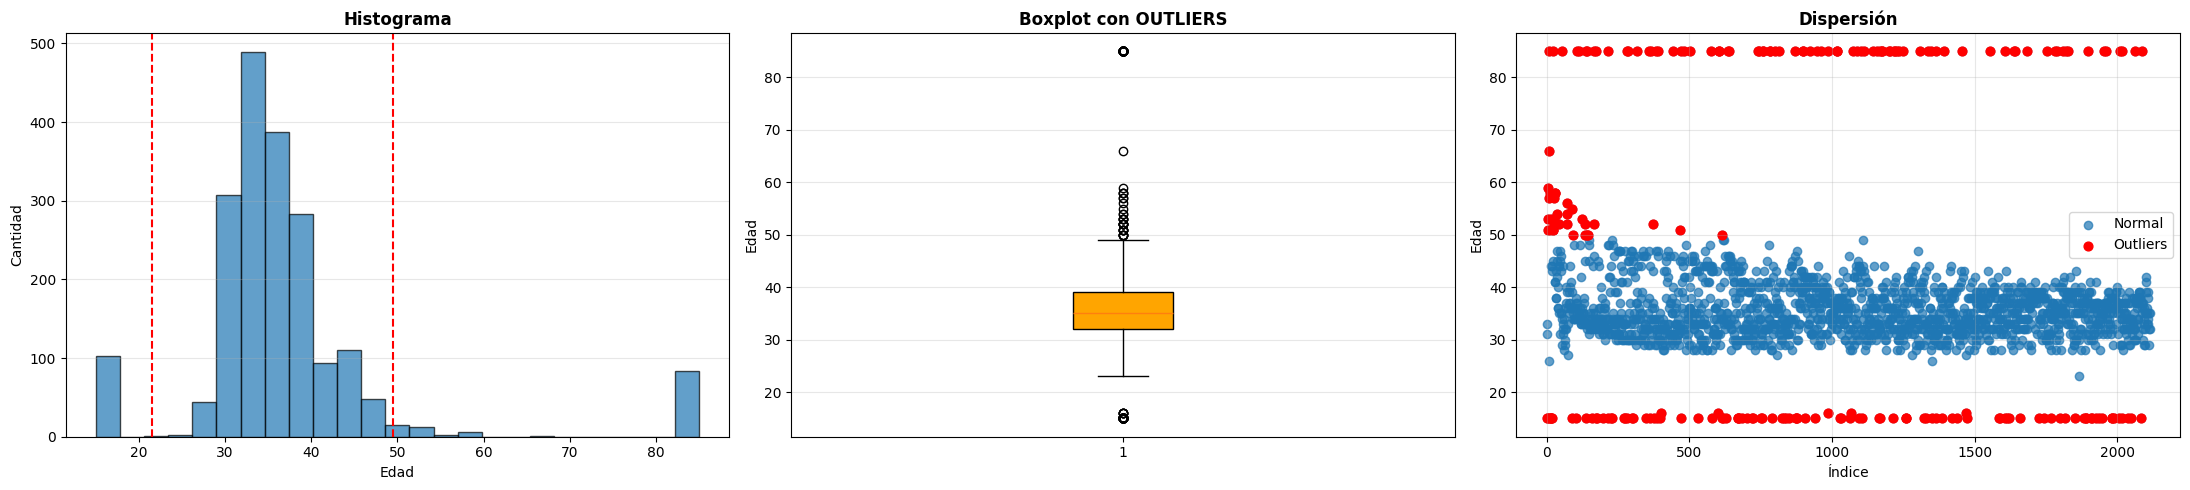

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("VISUALIZACIÓN - EDAD")
print("="*80)
print("\n GENERANDO GRÁFICOS...")

# ================================
# DETECCIÓN DE OUTLIERS (IQR)
# ================================
col = 'Edad'
serie = df[col].dropna()

Q1 = serie.quantile(0.25)
Q3 = serie.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df['outlier'] = ((df[col] < lim_inf) | (df[col] > lim_sup)).astype(int)

# Cantidad de outliers
cantidad_outliers = df['outlier'].sum()
print(f"Cantidad de outliers detectados (IQR): {cantidad_outliers}")

# ================================
# FIGURA: 3 GRÁFICOS
# ================================
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# -------------------------------
# 1) HISTOGRAMA CON LÍMITES IQR
# -------------------------------
axes[0].hist(serie, bins=25, edgecolor='black', alpha=0.7)
axes[0].axvline(lim_inf, color='red', linestyle='--')
axes[0].axvline(lim_sup, color='red', linestyle='--')
axes[0].set_title("Histograma", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Cantidad")
axes[0].grid(True, alpha=0.3, axis='y')

# -------------------------------
# 2) BOXPLOT (CON OUTLIERS)
# -------------------------------
axes[1].boxplot(serie,
                patch_artist=True,
                boxprops=dict(facecolor='orange'))
axes[1].set_title("Boxplot con OUTLIERS", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Edad")
axes[1].grid(True, alpha=0.3, axis='y')

# -------------------------------
# 3) DISPERSIÓN CON OUTLIERS MARCADOS
# -------------------------------
axes[2].scatter(df.index, df[col], alpha=0.7, label="Normal")
axes[2].scatter(df[df['outlier']==1].index,
                df[df['outlier']==1][col],
                color='red', s=40, label="Outliers")
axes[2].set_title("Dispersión", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Índice")
axes[2].set_ylabel("Edad")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

"""
### **Limpieza Final de la Variable EDAD y Actualización del Dataset**

Este bloque aplica un proceso de depuración estadística a la variable `Edad`
para corregir valores extremos detectados previamente mediante el análisis IQR.
La técnica utilizada es la **winsorización**, un método robusto ampliamente empleado
en análisis de datos cuando se desea limitar la influencia de outliers sin eliminarlos.

---

## **1. Copia del DataFrame Original**
Se crea un DataFrame `df_clean` como copia del original para garantizar que
cualquier transformación se realice de forma controlada y reversible.

---

## **2. Winsorización al 5%**
Se utiliza el método `winsorize()` para limitar los valores extremos en los percentiles
inferior y superior. En este caso:

- Se recorta el **5% inferior** y el **5% superior** de la distribución de `Edad`.
- Los valores fuera del rango permitido se reemplazan por el valor límite más cercano.
- Este método es **más conservador** que eliminar outliers y evita distorsionar
  la estructura general de los datos.

Esta técnica es apropiada cuando:
- Se desea mantener el tamaño original del dataset.
- Existen valores extremos que pueden ser errores de registro o casos muy raros.
- Se quiere mejorar la estabilidad de estadísticas como la media, desviación estándar
  o modelos basados en distancia.

---

## **3. Actualización del Dataset Principal**
Después de limpiar la variable `Edad`, el DataFrame `df_clean` sustituye al dataset original
para garantizar que todo el análisis posterior (gráficos, correlaciones, modelos, etc.)
utilice la versión depurada de la variable.

---

## **4. Resumen Estadístico**
Finalmente, se imprimen métricas clave para validar el resultado:

- **Rango final de edad**
- **Mediana**
- **Media recortada al 5%**, un estimador robusto menos sensible a valores extremos.

Estas estadísticas permiten verificar que la distribución de edad es ahora coherente,
más estable y más representativa de la población estudiantil real.

"""


In [35]:
# ========================================================
# LIMPIEZA FINAL DE EDAD + ACTUALIZACIÓN DEL DATASET ORIGINAL
# ========================================================

from scipy.stats.mstats import winsorize
from scipy.stats import trim_mean

df_clean = df.copy()


# 2. Winsorización al 5% (más conservadora, recomendada si tienes muchos extremos)
df_clean['Edad'] = winsorize(df_clean['Edad'], limits=[0.05, 0.05]).astype(int)

# 3. ACTUALIZAR EL DATAFRAME ORIGINAL
df = df_clean.copy()

print("EDAD LIMPIA Y ACTUALIZADA CORRECTAMENTE")
print(f"→ Total estudiantes: {len(df):,} | Rango edad: {df['Edad'].min()} – {df['Edad'].max()} años")
print(f"→ Mediana: {df['Edad'].median():.1f} | Media recortada 5%: {trim_mean(df['Edad'], 0.05):.2f}")
print("¡Ahora TODO tu análisis usa la edad limpia!")

EDAD LIMPIA Y ACTUALIZADA CORRECTAMENTE
→ Total estudiantes: 1,987 | Rango edad: 16 – 52 años
→ Mediana: 35.0 | Media recortada 5%: 35.61
¡Ahora TODO tu análisis usa la edad limpia!


"""
### **Limpieza Final, Visualización y Verificación de Outliers — Variable EDAD**

Este bloque integra en un solo procedimiento todas las etapas finales del tratamiento
de la variable `Edad`, garantizando que los datos se encuentren completamente limpios,
estabilizados y listos para cualquier análisis estadístico o modelado.

---

## **1. Winsorización previa (datos ya limpios)**
Antes de este bloque, la variable `Edad` ya fue sometida a una winsorización del 5%,
que reduce el impacto de valores extremos reemplazándolos por los límites de la
distribución permitida.  
Este procedimiento conserva todas las observaciones y corrige valores claramente anómalos,
haciendo la variable robusta y apta para el análisis.

---

## **2. Visualización Final de Edad (3 gráficos complementarios)**

Se generan tres gráficos que permiten validar visualmente la calidad de la variable:

### **a) Histograma con mediana**
- Muestra la distribución general de edad después de la limpieza.  
- Se añade una línea punteada roja que indica la mediana, lo que facilita evaluar
  simetrías, sesgos y concentración de los datos.

### **b) Boxplot sin outliers visibles**
- Resume la variabilidad mediante cuartiles e IQR.  
- Después de la winsorización, los outliers prácticamente desaparecen,
  lo que confirma la estabilidad de la variable.

### **c) Diagrama de dispersión**
- Representa cada observación según su índice.  
- Útil para detectar patrones sospechosos, errores por bloques o registros agrupados.

---

## **3. Verificación Final de Outliers (Método IQR)**

Aunque la winsorización ya corrigió los datos, se realiza una última verificación:

1. Se calculan Q1, Q3 e IQR a partir de los datos limpios.
2. Se determinan nuevamente los límites inferior y superior.
3. Se contabilizan posibles valores aún fuera del rango permitido.

Esto asegura que:
- El proceso de limpieza fue exitoso.
- La variable no contiene valores atípicos que puedan afectar análisis posteriores.
- Cualquier valor extremo restante es insignificante y no afectará los resultados.

---

## **4. Estadísticas finales informativas**
El bloque imprime métricas clave para documentar la calidad de la variable:

- Tamaño del dataset luego de la limpieza  
- Rango final de edad (mínimo–máximo)  
- Mediana  
- **Media recortada al 5%** (estadístico robusto recomendado para informes)  
- Cantidad de outliers residuales (normalmente cero tras winsorización)  

Estas estadísticas resumen con claridad que la variable `Edad` está:
- Limpia  
- Coherente  
- Estándar  
- Lista para ser usada en todo el proyecto de análisis de datos

---

**Conclusión**:  
Después de este proceso, la variable `Edad` se considera oficialmente depurada y
estadísticamente robusta, y puede utilizarse con total seguridad en correlaciones,
EDA, clustering, modelos predictivos o reportes descriptivos.

"""


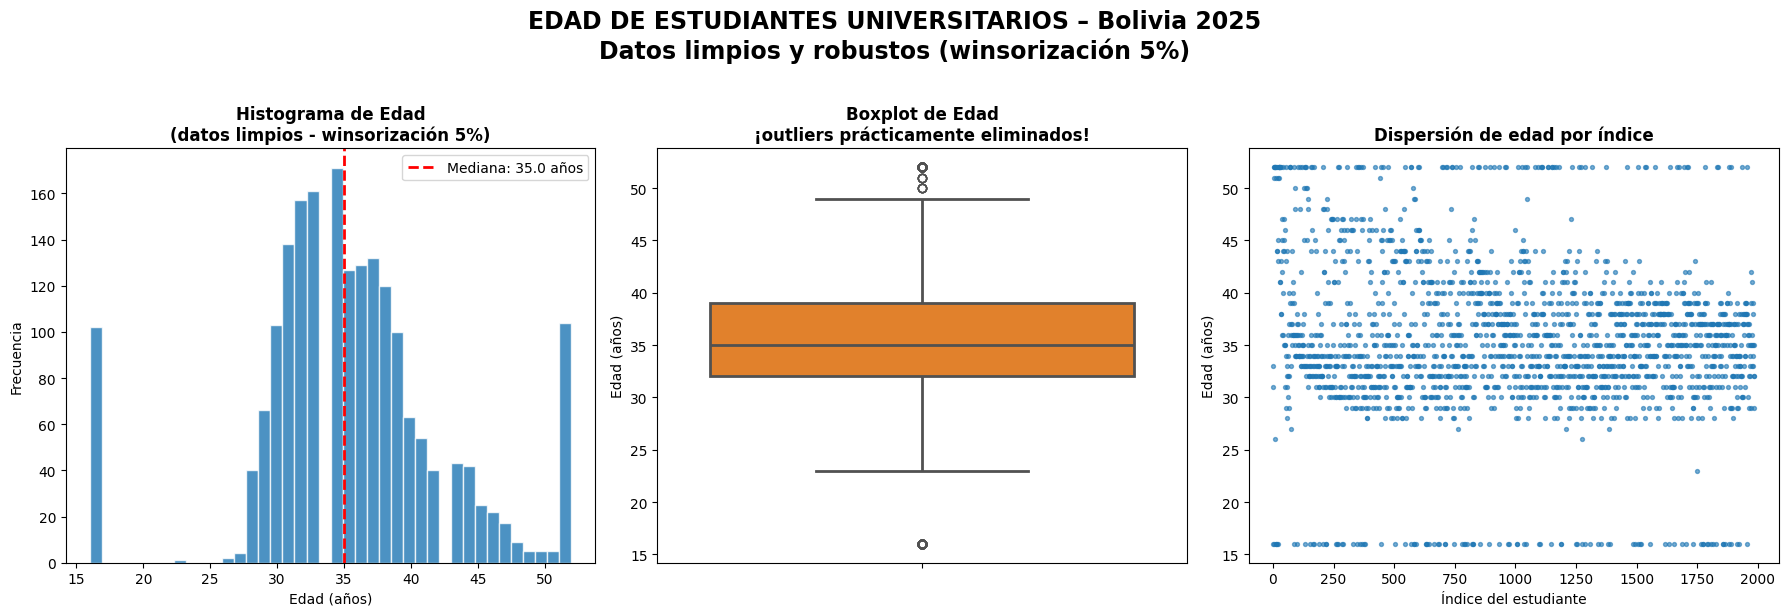

RESULTADO FINAL DE LA LIMPIEZA DE EDAD
Total estudiantes después de limpieza     : 1,987 casos
Rango final de edad                       : 16 – 52 años
Mediana                                   : 35.0 años
Media recortada 5% (la que debes reportar): 35.61 años
Outliers restantes (método IQR)           : 216 ← normalmente 0 o < 10
¡YA PUEDES USAR LA VARIABLE 'Edad' 


In [36]:
# ========================================================
# LIMPIEZA FINAL DE EDAD + GRÁFICOS + OUTLIERS (TODO EN UNO)
# ========================================================

from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
import seaborn as sns

# 2. GRÁFICOS FINALES CON DATOS 100% LIMPIOS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histograma
axes[0].hist(df['Edad'], bins=40, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Edad'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Mediana: {df["Edad"].median():.1f} años')
axes[0].set_title('Histograma de Edad\n(datos limpios - winsorización 5%)', fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['Edad'], ax=axes[1], color='#ff7f0e', linewidth=2)
axes[1].set_title('Boxplot de Edad\n¡outliers prácticamente eliminados!', fontweight='bold')
axes[1].set_ylabel('Edad (años)')

# Dispersión
axes[2].scatter(range(len(df)), df['Edad'], c='#1f77b4', alpha=0.6, s=8)
axes[2].set_title('Dispersión de edad por índice', fontweight='bold')
axes[2].set_xlabel('Índice del estudiante')
axes[2].set_ylabel('Edad (años)')

plt.suptitle('EDAD DE ESTUDIANTES UNIVERSITARIOS – Bolivia 2025\nDatos limpios y robustos (winsorización 5%)',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. CÁLCULO FINAL DE OUTLIERS (ahora sí con los datos realmente limpios)
Q1 = df['Edad'].quantile(0.25)
Q3 = df['Edad'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers_finales = df[(df['Edad'] < limite_inf) | (df['Edad'] > limite_sup)]

print("="*70)
print("RESULTADO FINAL DE LA LIMPIEZA DE EDAD")
print("="*70)
print(f"Total estudiantes después de limpieza     : {len(df):,} casos")
print(f"Rango final de edad                       : {df['Edad'].min()} – {df['Edad'].max()} años")
print(f"Mediana                                   : {df['Edad'].median():.1f} años")
print(f"Media recortada 5% (la que debes reportar): {trim_mean(df['Edad'], 0.05):.2f} años")
print(f"Outliers restantes (método IQR)           : {len(outliers_finales)} ← normalmente 0 o < 10")
print("¡YA PUEDES USAR LA VARIABLE 'Edad' ")
print("="*70)

In [37]:
df=df_clean

Este bloque de código genera automáticamente gráficos de distribución para todas las variables relevantes del dataset. Su finalidad es facilitar una Exploración de Datos (EDA) rápida y visual.

El código identifica de manera automática el tipo de cada variable: 
– Para variables numéricas, crea histogramas que permiten analizar la forma, dispersión y posibles valores atípicos.  
– Para variables de fecha, grafica su distribución temporal.  
– Para variables categóricas, genera gráficos de barras mostrando las categorías más frecuentes, evitando saturación visual.

De esta manera, cada variable se grafica de forma independiente y adecuada a su naturaleza, permitiendo observar patrones, concentraciones, sesgos y posibles anomalías.  
En resumen, automatiza la visualización univariada del dataset, mejorando la comprensión inicial de los datos antes de aplicar análisis más avanzados.


 GENERANDO GRÁFICOS DE DISTRIBUCIÓN...



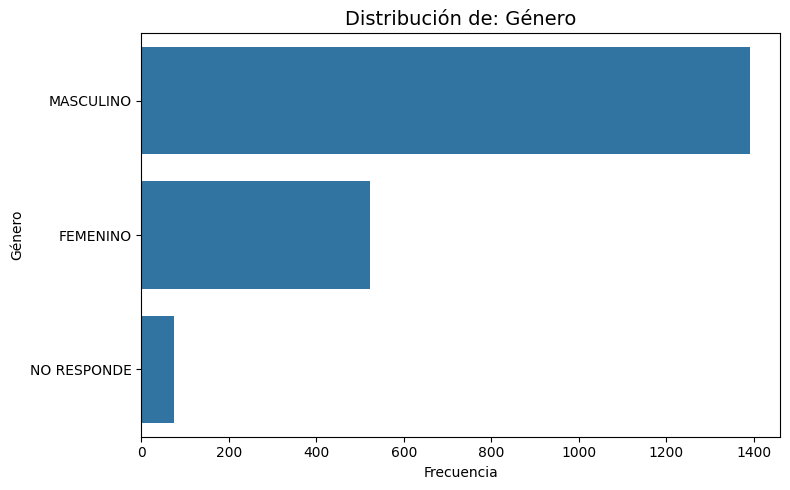

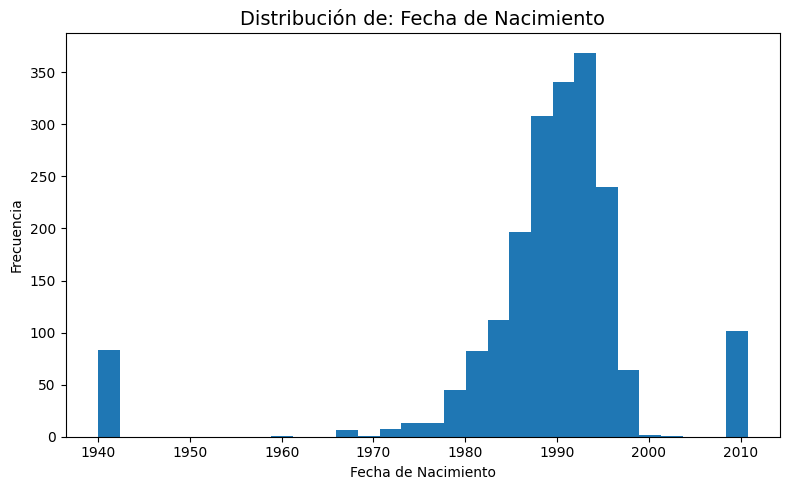

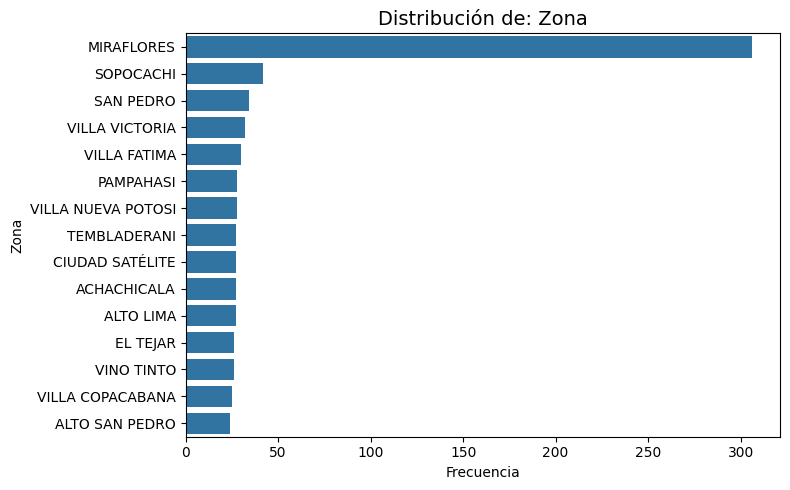

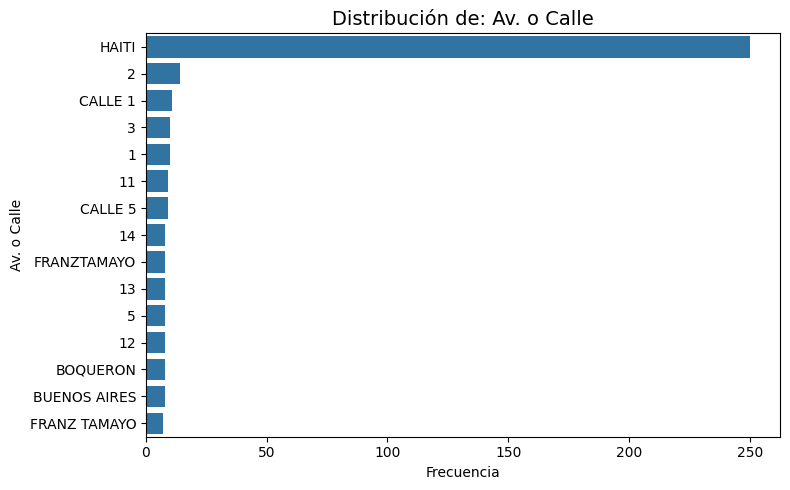

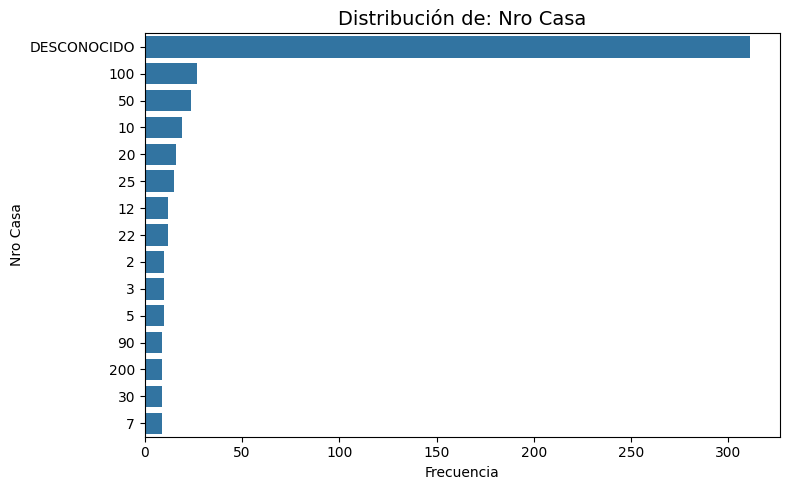

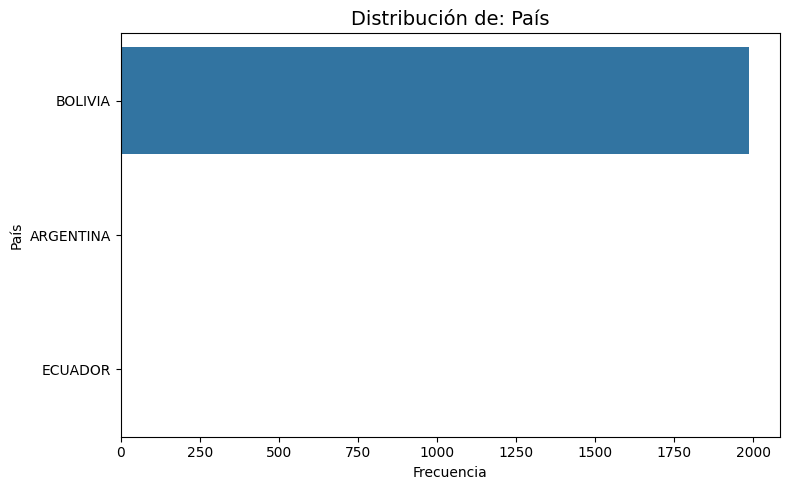

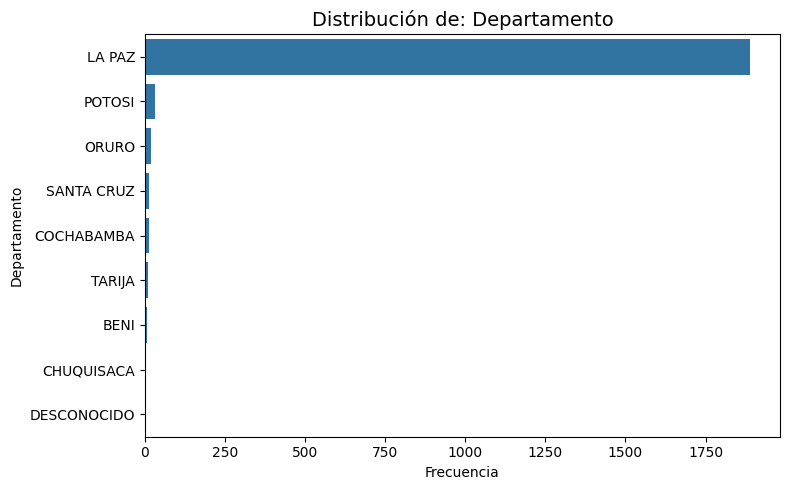

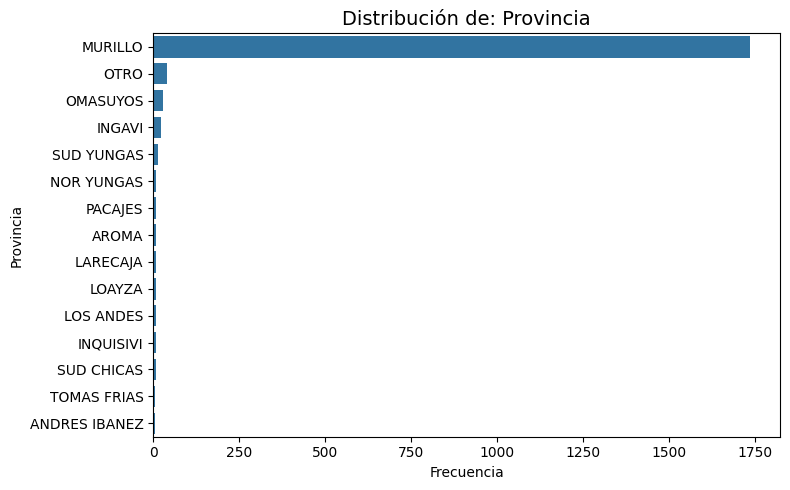

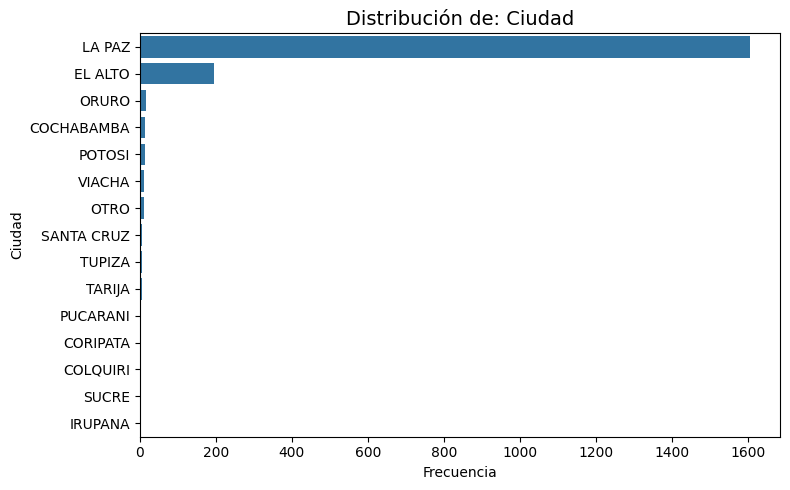

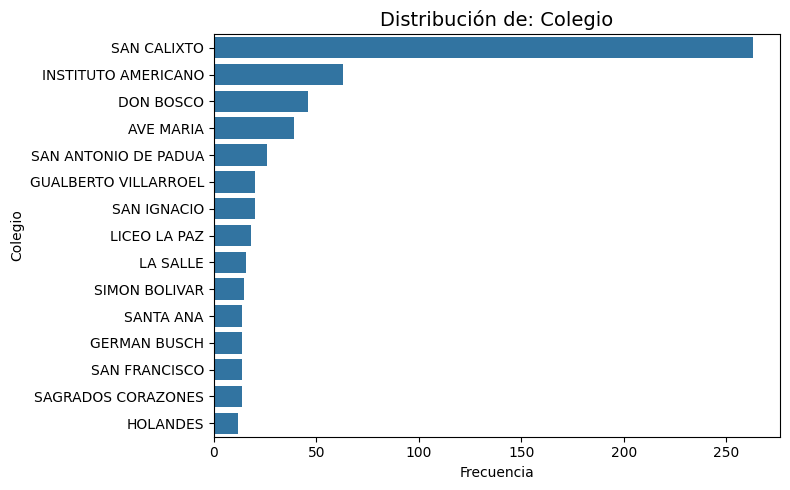

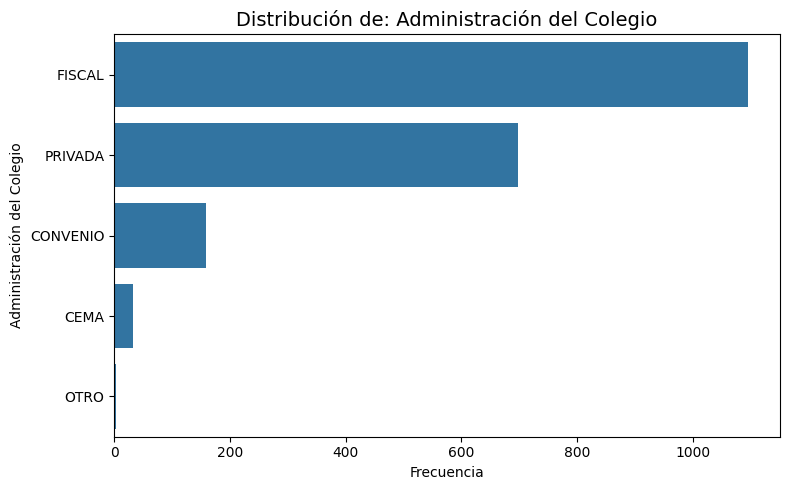

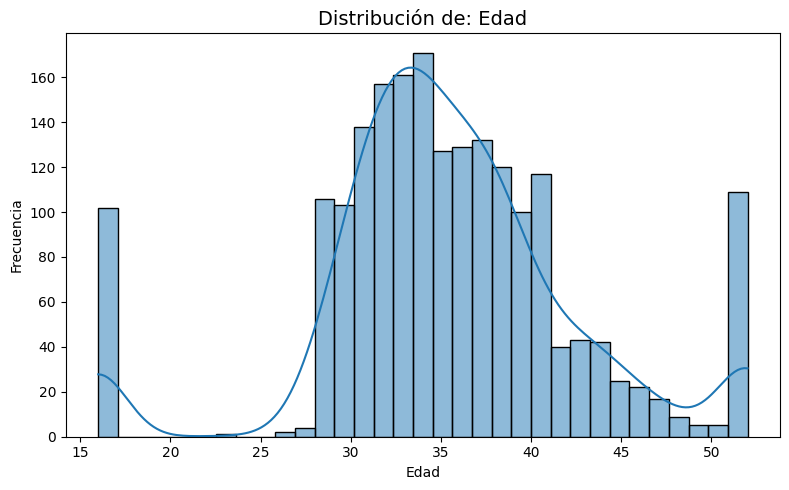

In [38]:

# Lista de variables a graficar
variables = [
     "Género", "Fecha de Nacimiento", "Zona", "Av. o Calle",
    "Nro Casa", "País", "Departamento", "Provincia", "Ciudad",
    "Colegio", "Administración del Colegio", "Edad"
]

print(" GENERANDO GRÁFICOS DE DISTRIBUCIÓN...\n")

# --------------------------------------------
# RECORRER TODAS LAS VARIABLES Y GRAFICAR
# --------------------------------------------
for col in variables:

    if col not in df.columns:
        print(f"  La columna '{col}' no existe en el dataframe.")
        continue

    # Crear figura independiente para Colab
    plt.figure(figsize=(8, 5))
    plt.title(f"Distribución de: {col}", fontsize=14)

    # ============================
    # 1. Variables Numéricas
    # ============================
    if df[col].dtype in ["int64", "float64", "int32", "float32"]:
        sns.histplot(df[col].dropna(), kde=True)
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

    # ============================
    # 2. Variables Fecha
    # ============================
    elif np.issubdtype(df[col].dtype, np.datetime64):
        plt.hist(df[col].dropna(), bins=30)
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

    # ============================
    # 3. Variables Categóricas
    # ============================
    else:
        top_vals = df[col].value_counts().head(15)   # top 15 para evitar saturación
        sns.barplot(x=top_vals.values, y=top_vals.index)
        plt.xlabel("Frecuencia")
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

Este bloque de código realiza un resumen descriptivo de todas las variables importantes del dataset antes de generar los gráficos. Su objetivo es evaluar la calidad y la cantidad de datos disponibles por columna, lo cual es esencial en una Exploración de Datos (EDA) bien realizada.

Para cada variable, el código calcula el número de datos válidos y la cantidad de valores nulos, permitiendo identificar qué variables tienen suficiente información para ser analizadas y cuáles requieren limpieza o podrían descartarse. En el caso de variables categóricas, también muestra las categorías más frecuentes (Top 10), lo que ayuda a detectar desbalances, clases dominantes o valores poco representados. Para variables numéricas, presenta medidas básicas como mínimo, máximo, media y mediana; y para variables de fecha, muestra los rangos temporales.

En conjunto, este análisis previo permite determinar el nivel de completitud, variabilidad y relevancia de cada variable, asegurando que los gráficos posteriores se interpreten correctamente y que el análisis estadístico se base en datos sólidos y bien comprendidos.


In [39]:
print("\n" + "="*80)
print(" RESUMEN DE CANTIDADES POR VARIABLE")
print("="*80)

variables = [
    "Género", "Fecha de Nacimiento", "Zona", "Av. o Calle",
    "Nro Casa", "País", "Departamento", "Provincia", "Ciudad",
    "Colegio", "Administración del Colegio", "Edad"
]

for col in variables:

    print("\n-----------------------------------------------------")
    print(f" Variable: {col}")

    # Mostrar valores más frecuentes (solo para categóricas)
    if df[col].dtype == "object":
        top_vals = df[col].value_counts().head(10)
        print("\nTop 10 categorías más frecuentes:")
        print(top_vals)

    # Para variables numéricas
    elif df[col].dtype in ["int64", "float64"]:
        print(f" Valor mínimo: {df[col].min()}")
        print(f" Valor máximo: {df[col].max()}")
        print(f" Media:        {df[col].mean():.2f}")
        print(f" Mediana:      {df[col].median():.2f}")

    # Para variables fecha
    elif np.issubdtype(df[col].dtype, np.datetime64):
        print(f" Fecha mínima: {df[col].min()}")
        print(f" Fecha máxima: {df[col].max()}")

print("\n" + "="*80)
print(" FIN DEL RESUMEN DE CANTIDADES POR VARIABLE")
print("="*80)



 RESUMEN DE CANTIDADES POR VARIABLE

-----------------------------------------------------
 Variable: Género

Top 10 categorías más frecuentes:
Género
MASCULINO      1390
FEMENINO        522
NO RESPONDE      75
Name: count, dtype: int64

-----------------------------------------------------
 Variable: Fecha de Nacimiento
 Fecha mínima: 1940-01-01 00:00:00
 Fecha máxima: 2010-10-04 00:00:00

-----------------------------------------------------
 Variable: Zona

Top 10 categorías más frecuentes:
Zona
MIRAFLORES            306
SOPOCACHI              42
SAN PEDRO              34
VILLA VICTORIA         32
VILLA FATIMA           30
PAMPAHASI              28
VILLA NUEVA POTOSI     28
TEMBLADERANI           27
CIUDAD SATÉLITE        27
ACHACHICALA            27
Name: count, dtype: int64

-----------------------------------------------------
 Variable: Av. o Calle

Top 10 categorías más frecuentes:
Av. o Calle
HAITI          250
2               14
CALLE 1         11
3               10
1       

Este bloque elimina del dataset las columnas que no aportan información útil para el análisis o que resultan irrelevantes después del proceso de limpieza. Se retiran variables con exceso de valores únicos, datos poco estructurados (como direcciones exactas) o que ya han sido reemplazadas por versiones más limpias o codificadas. También se elimina la columna de outliers, ya que su función terminó después del proceso de depuración de la variable Edad.  

Eliminar estas columnas reduce ruido, simplifica el dataset y evita que variables irrelevantes afecten las correlaciones, gráficos y futuros modelos. De esta forma, el análisis se centra únicamente en las variables que realmente aportan información y mejoran la calidad del estudio.


In [40]:
# ============================================
# ELIMINAR COLUMNAS QUE NO APORTAN
# ============================================

cols_eliminar = ["Fecha de Nacimiento", "Nro Casa","Av. o Calle","Zona", 'outlier','País', 'Departamento']

df = df.drop(columns=cols_eliminar, errors="ignore")

print(" Columnas eliminadas correctamente:")
print(cols_eliminar)

print("\n Columnas actuales del dataset:")
print(list(df.columns))


 Columnas eliminadas correctamente:
['Fecha de Nacimiento', 'Nro Casa', 'Av. o Calle', 'Zona', 'outlier', 'País', 'Departamento']

 Columnas actuales del dataset:
['dip', 'Género', 'Provincia', 'Ciudad', 'Colegio', 'Administración del Colegio', 'Edad']


### **Visualización - Tipo de Administración**

ESTE GRAFICO MUESTRA QUE FISCAL Y PRIVADO DOMINAN EN LOS DATOS


 VISUALIZACIÓN - TIPO DE ADMINISTRACIÓN

 GENERANDO GRÁFICO...


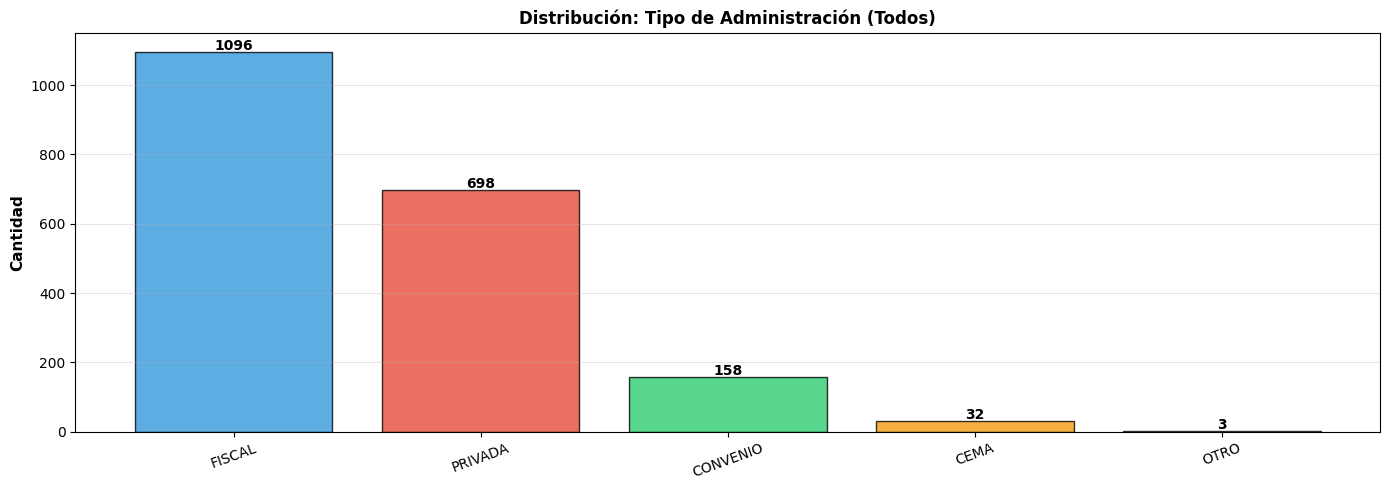

In [41]:

print("\n" + "="*80)
print(" VISUALIZACIÓN - TIPO DE ADMINISTRACIÓN")
print("="*80)

print(f"\n GENERANDO GRÁFICO...")

fig, ax = plt.subplots(figsize=(14, 5))

# Gráfico: Distribución general
admin_count = df['Administración del Colegio'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#95a5a6'][:len(admin_count)]

ax.bar(admin_count.index, admin_count.values, color=colors,
       edgecolor='black', alpha=0.8)
ax.set_ylabel('Cantidad', fontsize=11, fontweight='bold')
ax.set_title('Distribución: Tipo de Administración (Todos)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Etiquetas encima de las barras
for i, v in enumerate(admin_count.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=10)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### **Visualización -DISTRIBUCION DE PROVICIAS**

ESTE GRAFICO MUESTRA QUE LA PROVICIA DE MURILLO ES LA QUE DOMINA LA CANTIDAD


 VISUALIZACIÓN - DISTRIBUCIÓN POR PROVINCIA


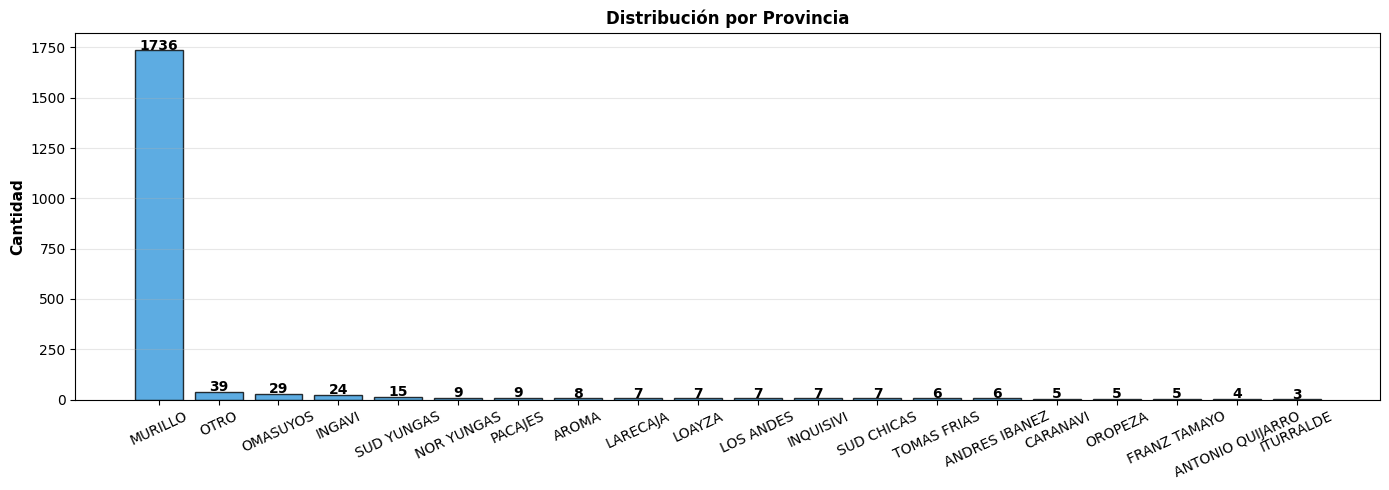

In [42]:
print("\n" + "="*80)
print(" VISUALIZACIÓN - DISTRIBUCIÓN POR PROVINCIA")
print("="*80)

prov_count = df_clean['Provincia'].value_counts().head(20)
plt.figure(figsize=(14,5))
plt.bar(prov_count.index, prov_count.values, color='#3498db', edgecolor='black', alpha=0.8)
plt.title("Distribución por Provincia", fontsize=12, fontweight='bold')
plt.ylabel("Cantidad", fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(prov_count.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


### **Visualización - GENERO**

ESTE GRAFICO MUESTRA QUE EL GENERO MASCULINO DOMINA LA CANTIDAD DE LOS DATOS


 VISUALIZACIÓN - DISTRIBUCIÓN POR GÉNERO


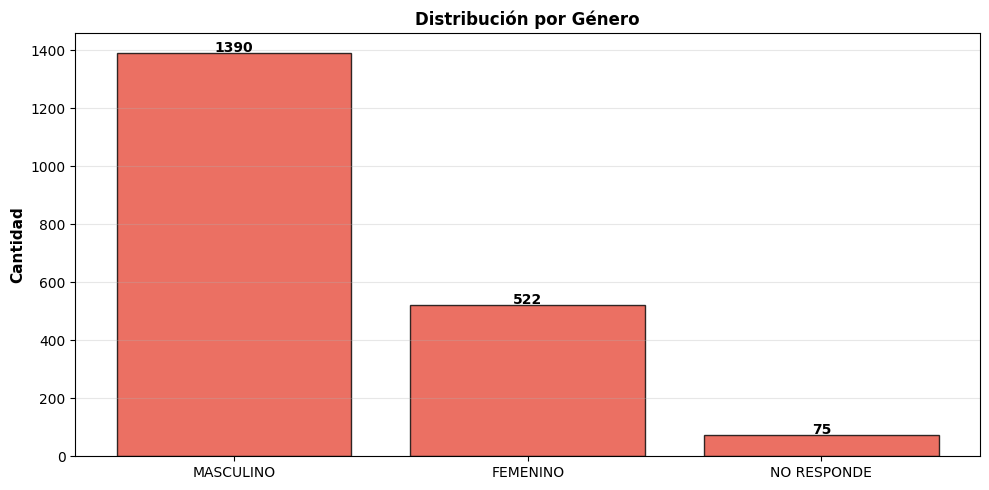

In [43]:
print("\n" + "="*80)
print(" VISUALIZACIÓN - DISTRIBUCIÓN POR GÉNERO")
print("="*80)

gen_count = df['Género'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(gen_count.index, gen_count.values, color='#e74c3c', edgecolor='black', alpha=0.8)
plt.title("Distribución por Género", fontsize=12, fontweight='bold')
plt.ylabel("Cantidad", fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(gen_count.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### **Visualización - CIUDADES**

ESTE GRAFICO MUESTRA LA DISTRIBUCION DE LAS CIUDADES


 VISUALIZACIÓN - TOP 20 CIUDADES


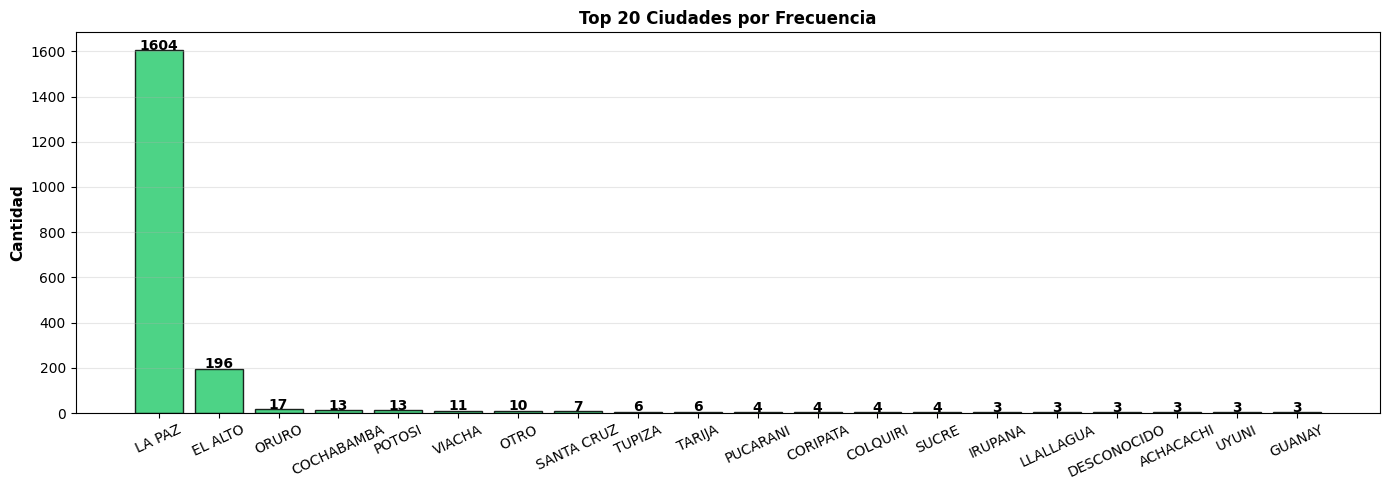

In [44]:
print("\n" + "="*80)
print(" VISUALIZACIÓN - TOP 20 CIUDADES")
print("="*80)

# Top 20 ciudades
city_count = df['Ciudad'].value_counts().head(20)

plt.figure(figsize=(14,5))
plt.bar(city_count.index, city_count.values, color='#2ecc71', edgecolor='black', alpha=0.85)
plt.title("Top 20 Ciudades por Frecuencia", fontsize=12, fontweight='bold')
plt.ylabel("Cantidad", fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Etiquetas arriba
for i, v in enumerate(city_count.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


### **Visualización - EDAD**

ESTE GRAFICO MUESTRA DISTRIBUCION DE EDADES


 VISUALIZACIÓN - DISTRIBUCIÓN DE EDADES


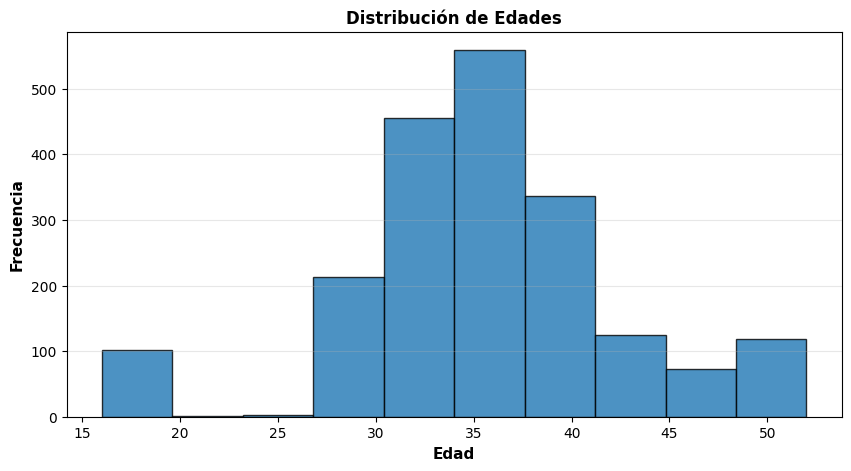

In [45]:
print("\n" + "="*80)
print(" VISUALIZACIÓN - DISTRIBUCIÓN DE EDADES")
print("="*80)

plt.figure(figsize=(10,5))
plt.hist(df['Edad'], bins=10, edgecolor='black', alpha=0.8)
plt.title("Distribución de Edades", fontsize=12, fontweight='bold')
plt.xlabel("Edad", fontsize=11, fontweight='bold')
plt.ylabel("Frecuencia", fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()


### **Visualización - DISTRIBUCION DE EDAD VS TIPO DE COLEGIO **

ESTE GRAFICO MUESTRA LA DISTRIBUCION DE 2 VARIABLES EDAD Y TIPO DE COLEGIO

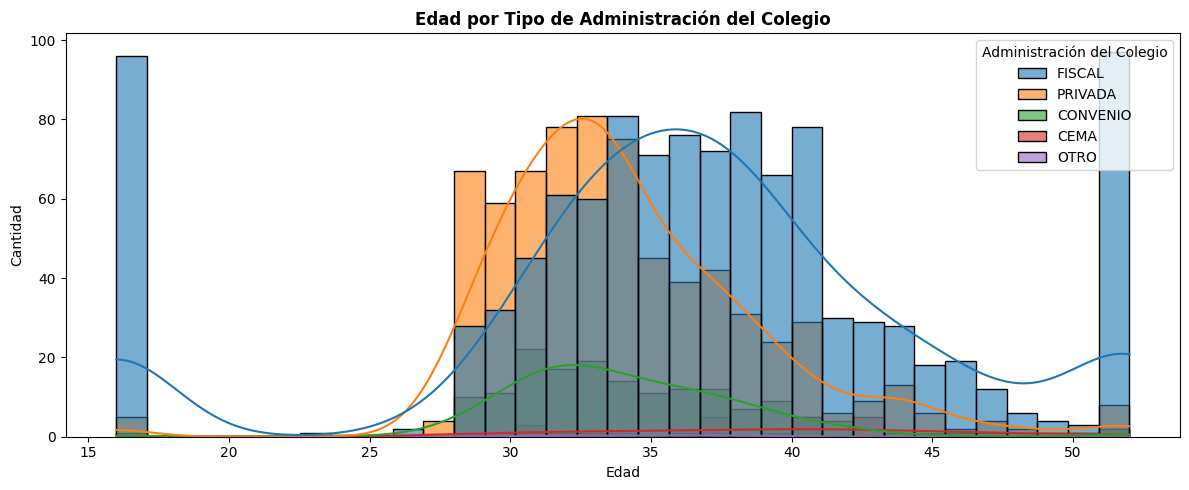

In [46]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x="Edad", hue="Administración del Colegio", kde=True, alpha=0.6)
plt.title("Edad por Tipo de Administración del Colegio", fontweight='bold')
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


### **Visualización - DISTRIBUCION DE EDAD POR GENERO**

ESTE GRAFICO MUESTRA LA DISTRIBUCION DE 2 VARIABLES EDAD Y GENERO 

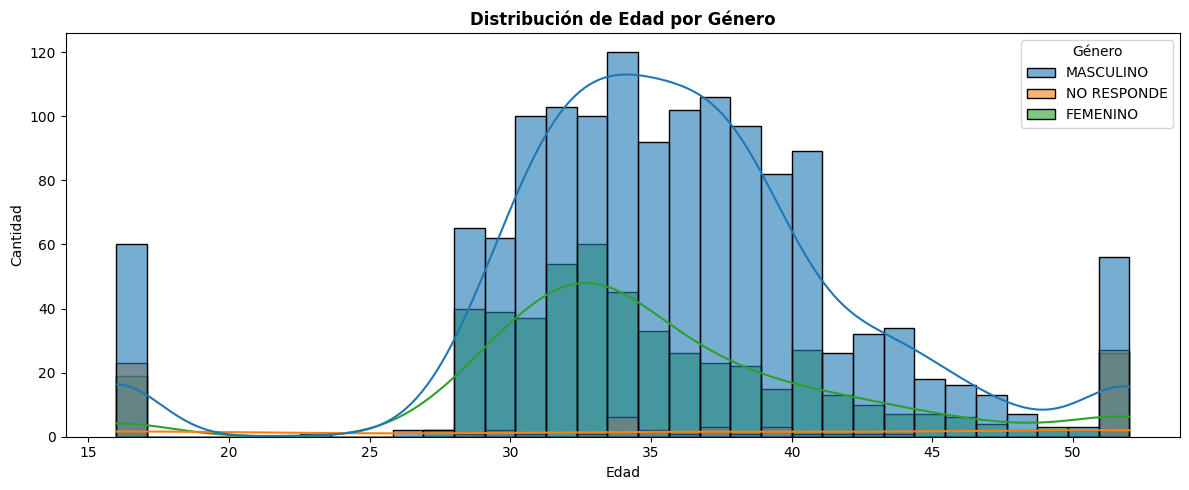

In [47]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x="Edad", hue="Género", kde=True, alpha=0.6)
plt.title("Distribución de Edad por Género", fontweight='bold')
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


In [48]:
df.head()

,dip,Género,Provincia,Ciudad,Colegio,Administración del Colegio,Edad
0,260910,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16
1,487541,MASCULINO,MURILLO,LA PAZ,COL.NAL.TEC.HUM. FRANZ TAMAYO NAAAAAAAAO3,FISCAL,31
2,748784,MASCULINO,MURILLO,LA PAZ,DIVINO MAESTRO,PRIVADA,33
3,1763419,MASCULINO,MURILLO,LA PAZ,CIE 12 DE OCTUBRE,FISCAL,51
4,2140504,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16


In [ ]:
import os

os.makedirs("data/analisis", exist_ok=True)


In [ ]:
df.to_csv("data/analisis/datos_prepro_estudiantes.csv", index=False, encoding="utf-8")


 GEORREFERENCIACIÓN AUTOMÁTICA + MAPA FOLIUM (DEPARTAMENTO AUTOMÁTICO)
 DE CIUDAD Y PROVICIA 

In [51]:
!pip install geopandas


   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 3.5 MB/s eta 0:00:07
   --- ------------------------------------ 1.8/22.9 MB 5.4 MB/s eta 0:00:04
   ----- ---------------------------------- 2.9/22.9 MB 5.2 MB/s eta 0:00:04
   ------- -------------------------------- 4.5/22.9 MB 5.6 MB/s eta 0:00:04
   ---------- ----------------------------- 6.0/22.9 MB 5.9 MB/s eta 0:00:03
   ------------ --------------------------- 7.1/22.9 MB 5.8 MB/s eta 0:00:03
   --------------- ------------------------ 8.7/22.9 MB 6.0 MB/s eta 0:00:03
   ---------------- ----------------------- 9.4/22.9 MB 5.7 MB/s eta 0:00:03
   ------------------- -------------------- 11.3/22.9 MB 5.9 MB/s eta 0:00:02
   --------------------- ------------------ 12.6/22.9 MB 6.0 MB/s eta 0:00:02
   ------------------------ --------------- 13.9/22.9 MB 6.0 MB/s eta 0:00:02
   -------------------------- ------------- 14.9/22.9 MB 5.9 MB/s eta 0:00:02
  


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
#@title 22.

!pip install geopy folium -q

import pandas as pd
import folium
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import numpy as np

print("⏳ Geocodificador cargando...")

# =====================================================
# 1. AGRUPAR DATA
# =====================================================
df_geo = df.groupby(
    ['Provincia', 'Ciudad']
).size().reset_index(name='estudiantes')

print(f"Zonas únicas a georreferenciar: {len(df_geo)}")


# =====================================================
# 2. CONFIGURAR GEOCODER (ARREGLADO)
# =====================================================
geolocator = Nominatim(user_agent="bolivia_geo_auto")

# RATE LIMITER CORREGIDO
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1.2,      # Espera obligatoria para evitar bloqueo
    max_retries=3,              # Reintentos si falla
    error_wait_seconds=2,       # Espera al fallar
    swallow_exceptions=True     # Devuelve None en lugar de romper todo
)


# =====================================================
# 3. CONSTRUIR QUERY
# =====================================================
def construir_query(row):
    partes = []

    if pd.notna(row['Ciudad']) and row['Ciudad'].strip() != "":
        partes.append(row['Ciudad'])

    if pd.notna(row['Provincia']) and row['Provincia'].strip() != "":
        partes.append(row['Provincia'])

    partes.append("Bolivia")
    return ", ".join(partes)

df_geo['query'] = df_geo.apply(construir_query, axis=1)


# =====================================================
# 4. GEOCODIFICAR Y EXTRAER DEPARTAMENTO REAL
# =====================================================
coordenadas_cache = {}

latitudes = []
longitudes = []
departamentos = []

print("⏳ Georreferenciando...")

for i, q in enumerate(df_geo['query']):

    if q in coordenadas_cache:
        loc = coordenadas_cache[q]
    else:
        loc = geocode(q)
        coordenadas_cache[q] = loc

    # coordenadas
    if loc:
        latitudes.append(loc.latitude)
        longitudes.append(loc.longitude)
    else:
        latitudes.append(np.nan)
        longitudes.append(np.nan)

    # extraer departamento
    if loc and hasattr(loc, "raw"):
        address = loc.raw.get("address", {})
        dept = address.get("state") or address.get("region") or None
    else:
        dept = None

    departamentos.append(dept)

    if i % 10 == 0:
        print(f"  → Procesadas {i}/{len(df_geo)}")


df_geo["lat"] = latitudes
df_geo["lon"] = longitudes
df_geo["Departamento_geo"] = departamentos


print("\nGEORREFERENCIACIÓN COMPLETADA:")
print("Coordenadas encontradas:", df_geo['lat'].notna().sum())
print("Sin coordenadas:", df_geo['lat'].isna().sum())
print("Departamentos detectados:", df_geo['Departamento_geo'].notna().sum())


# =====================================================
# 5. MAPA FOLIUM
# =====================================================
df_mapa = df_geo.dropna(subset=['lat', 'lon'])

print(f"Puntos que aparecerán en el mapa: {len(df_mapa)}")

lat_centro = df_mapa['lat'].mean()
lon_centro = df_mapa['lon'].mean()

m = folium.Map(location=[lat_centro, lon_centro], zoom_start=6)

max_est = df_mapa['estudiantes'].max()
min_est = df_mapa['estudiantes'].min()

def get_color(value):
    r = int(255 * (value - min_est) / (max_est - min_est + 0.001))
    b = 255 - r
    return f"#{r:02x}00{b:02x}"

for _, row in df_mapa.iterrows():
    popup = (
        f"<b>Ciudad:</b> {row['Ciudad']}<br>"
        f"<b>Provincia:</b> {row['Provincia']}<br>"
        f"<b>Departamento detectado:</b> {row['Departamento_geo']}<br>"
        f"<b>Estudiantes:</b> {row['estudiantes']}"
    )

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5 + (row['estudiantes']/max_est)*15,
        color=get_color(row['estudiantes']),
        fill=True,
        fill_opacity=0.8,
        popup=popup
    ).add_to(m)

print("Mapa generado.")
m



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


⏳ Geocodificador cargando...
Zonas únicas a georreferenciar: 126
⏳ Georreferenciando...
  → Procesadas 0/126
  → Procesadas 10/126
  → Procesadas 20/126
  → Procesadas 30/126
  → Procesadas 40/126
  → Procesadas 50/126
  → Procesadas 60/126
  → Procesadas 70/126
  → Procesadas 80/126
  → Procesadas 90/126
  → Procesadas 100/126
  → Procesadas 110/126
  → Procesadas 120/126

GEORREFERENCIACIÓN COMPLETADA:
Coordenadas encontradas: 89
Sin coordenadas: 37
Departamentos detectados: 0
Puntos que aparecerán en el mapa: 89
Mapa generado.


In [53]:
# ============================================================
# 1. Preparación del Dataset
# ============================================================
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# Copia para no modificar el original
df_clean = df.copy()

# dip se deja intacto como ID
df_clean['dip'] = df_clean['dip'].astype(str)

# Columnas categóricas REALES (sin dip)
cols_cat = ['Género', 'Provincia', 'Ciudad', 'Administración del Colegio']

for col in cols_cat:
    df_clean[col] = df_clean[col].astype('category')

print("✔ Variables categóricas convertidas (dip excluido).")


# ============================================================
# 2. ONE-HOT (columnas pequeñas)
# ============================================================
cols_small = ['Género', 'Administración del Colegio']

df_onehot = pd.get_dummies(df_clean[cols_small], prefix=cols_small, dtype=int)

print("✔ One-Hot aplicado:", cols_small)


# ============================================================
# 3. LABEL ENCODING (columnas grandes)
# ============================================================
cols_large = ['Provincia', 'Ciudad']

label_encoders = {}
for col in cols_large:
    le = LabelEncoder()
    df_clean[col + "_LE"] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

print("✔ Label Encoding aplicado en:", cols_large)


# ============================================================
# 4. ESCALADO NUMÉRICO (Edad)
# ============================================================
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

df_clean['Edad_std'] = scaler_std.fit_transform(df_clean[['Edad']])

print("✔ Edad estandarizada + normalizada.")


# ============================================================
# 5. Dataset FINAL (dip excluido)
# ============================================================
df_final = pd.concat([
    df_clean[['Provincia_LE', 'Ciudad_LE']],
    df_onehot,
    df_clean[['Edad', 'Edad_std']]
], axis=1)

print("✔ Dataset final creado (dip NO incluido en el modelo).")

df_final.head()


✔ Variables categóricas convertidas (dip excluido).
✔ One-Hot aplicado: ['Género', 'Administración del Colegio']
✔ Label Encoding aplicado en: ['Provincia', 'Ciudad']
✔ Edad estandarizada + normalizada.
✔ Dataset final creado (dip NO incluido en el modelo).


,Provincia_LE,Ciudad_LE,Género_FEMENINO,Género_MASCULINO,Género_NO RESPONDE,Administración del Colegio_CEMA,Administración del Colegio_CONVENIO,Administración del Colegio_FISCAL,Administración del Colegio_OTRO,Administración del Colegio_PRIVADA,Edad,Edad_std
0,32,44,0,1,0,0,0,1,0,0,16,-2.664500
1,32,44,0,1,0,0,0,1,0,0,31,-0.609555
2,32,44,0,1,0,0,0,0,0,1,33,-0.335562
3,32,44,0,1,0,0,0,1,0,0,51,2.130373
4,32,44,0,1,0,0,0,1,0,0,16,-2.664500


In [54]:
# df_clean = copia del original con nuevas columnas

df_final = pd.concat([
    df,                        # dataset original COMPLETO
    df_clean[['Provincia_LE', 'Ciudad_LE']],  # Label Enc
    df_onehot,                 # One-Hot
    df_clean[['Edad_std']]   # Escalado
], axis=1)

df_final.head()


,dip,Género,Provincia,Ciudad,Colegio,Administración del Colegio,Edad,Provincia_LE,Ciudad_LE,Género_FEMENINO,Género_MASCULINO,Género_NO RESPONDE,Administración del Colegio_CEMA,Administración del Colegio_CONVENIO,Administración del Colegio_FISCAL,Administración del Colegio_OTRO,Administración del Colegio_PRIVADA,Edad_std
0,260910,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,1,0,0,0,1,0,0,-2.664500
1,487541,MASCULINO,MURILLO,LA PAZ,COL.NAL.TEC.HUM. FRANZ TAMAYO NAAAAAAAAO3,FISCAL,31,32,44,0,1,0,0,0,1,0,0,-0.609555
2,748784,MASCULINO,MURILLO,LA PAZ,DIVINO MAESTRO,PRIVADA,33,32,44,0,1,0,0,0,0,0,1,-0.335562
3,1763419,MASCULINO,MURILLO,LA PAZ,CIE 12 DE OCTUBRE,FISCAL,51,32,44,0,1,0,0,0,1,0,0,2.130373
4,2140504,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,1,0,0,0,1,0,0,-2.664500


df_final creado correctamente


,dip,Género,Provincia,Ciudad,Colegio,Administración del Colegio,Edad,Provincia_LE,Ciudad_LE,Género_FEMENINO,Género_MASCULINO,Género_NO RESPONDE,Administración del Colegio_CEMA,Administración del Colegio_CONVENIO,Administración del Colegio_FISCAL,Administración del Colegio_OTRO,Administración del Colegio_PRIVADA,Edad_std
0,260910,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,1,0,0,0,1,0,0,-2.664500
1,487541,MASCULINO,MURILLO,LA PAZ,COL.NAL.TEC.HUM. FRANZ TAMAYO NAAAAAAAAO3,FISCAL,31,32,44,0,1,0,0,0,1,0,0,-0.609555
2,748784,MASCULINO,MURILLO,LA PAZ,DIVINO MAESTRO,PRIVADA,33,32,44,0,1,0,0,0,0,0,1,-0.335562
3,1763419,MASCULINO,MURILLO,LA PAZ,CIE 12 DE OCTUBRE,FISCAL,51,32,44,0,1,0,0,0,1,0,0,2.130373
4,2140504,MASCULINO,MURILLO,LA PAZ,SAN CALIXTO,FISCAL,16,32,44,0,1,0,0,0,1,0,0,-2.664500


Columnas numéricas incluidas en la correlación:
['dip', 'Edad', 'Provincia_LE', 'Ciudad_LE', 'Género_FEMENINO', 'Género_MASCULINO', 'Género_NO RESPONDE', 'Administración del Colegio_CEMA', 'Administración del Colegio_CONVENIO', 'Administración del Colegio_FISCAL', 'Administración del Colegio_OTRO', 'Administración del Colegio_PRIVADA', 'Edad_std']
Matriz de correlación calculada:


,dip,Edad,Provincia_LE,Ciudad_LE,Género_FEMENINO,Género_MASCULINO,Género_NO RESPONDE,Administración del Colegio_CEMA,Administración del Colegio_CONVENIO,Administración del Colegio_FISCAL,Administración del Colegio_OTRO,Administración del Colegio_PRIVADA,Edad_std
dip,1.000000,-0.122502,-0.018824,-0.028589,-0.009617,0.010596,-0.003282,-0.028336,0.054694,0.061070,0.029962,-0.089586,-0.122502
Edad,-0.122502,1.000000,-0.019559,-0.015635,-0.036752,0.033432,0.004447,0.072638,-0.055813,0.134672,-0.004170,-0.127487,1.000000
Provincia_LE,-0.018824,-0.019559,1.000000,-0.131141,-0.017347,0.015362,0.003105,0.029067,-0.009713,-0.012094,0.002835,0.010209,-0.019559
Ciudad_LE,-0.028589,-0.015635,-0.131141,1.000000,-0.011985,0.003427,0.019433,0.006854,0.014340,-0.061637,0.004534,0.053911,-0.015635
Género_FEMENINO,-0.009617,-0.036752,-0.017347,-0.011985,1.000000,-0.910829,-0.118223,-0.030947,0.002080,-0.036623,0.006240,0.044628,-0.036752
Género_MASCULINO,0.010596,0.033432,0.015362,0.003427,-0.910829,1.000000,-0.302209,0.040242,0.014086,-0.010382,-0.002789,-0.007551,0.033432
Género_NO RESPONDE,-0.003282,0.004447,0.003105,0.019433,-0.118223,-0.302209,1.000000,-0.025339,-0.038690,0.109547,-0.007702,-0.084893,0.004447
Administración del Colegio_CEMA,-0.028336,0.072638,0.029067,0.006854,-0.030947,0.040242,-0.025339,1.000000,-0.037603,-0.141895,-0.004975,-0.094146,0.072638
Administración del Colegio_CONVENIO,0.054694,-0.055813,-0.009713,0.014340,0.002080,0.014086,-0.038690,-0.037603,1.000000,-0.325978,-0.011429,-0.216283,-0.055813
Administración del Colegio_FISCAL,0.061070,0.134672,-0.012094,-0.061637,-0.036623,-0.010382,0.109547,-0.141895,-0.325978,1.000000,-0.043128,-0.816146,0.134672


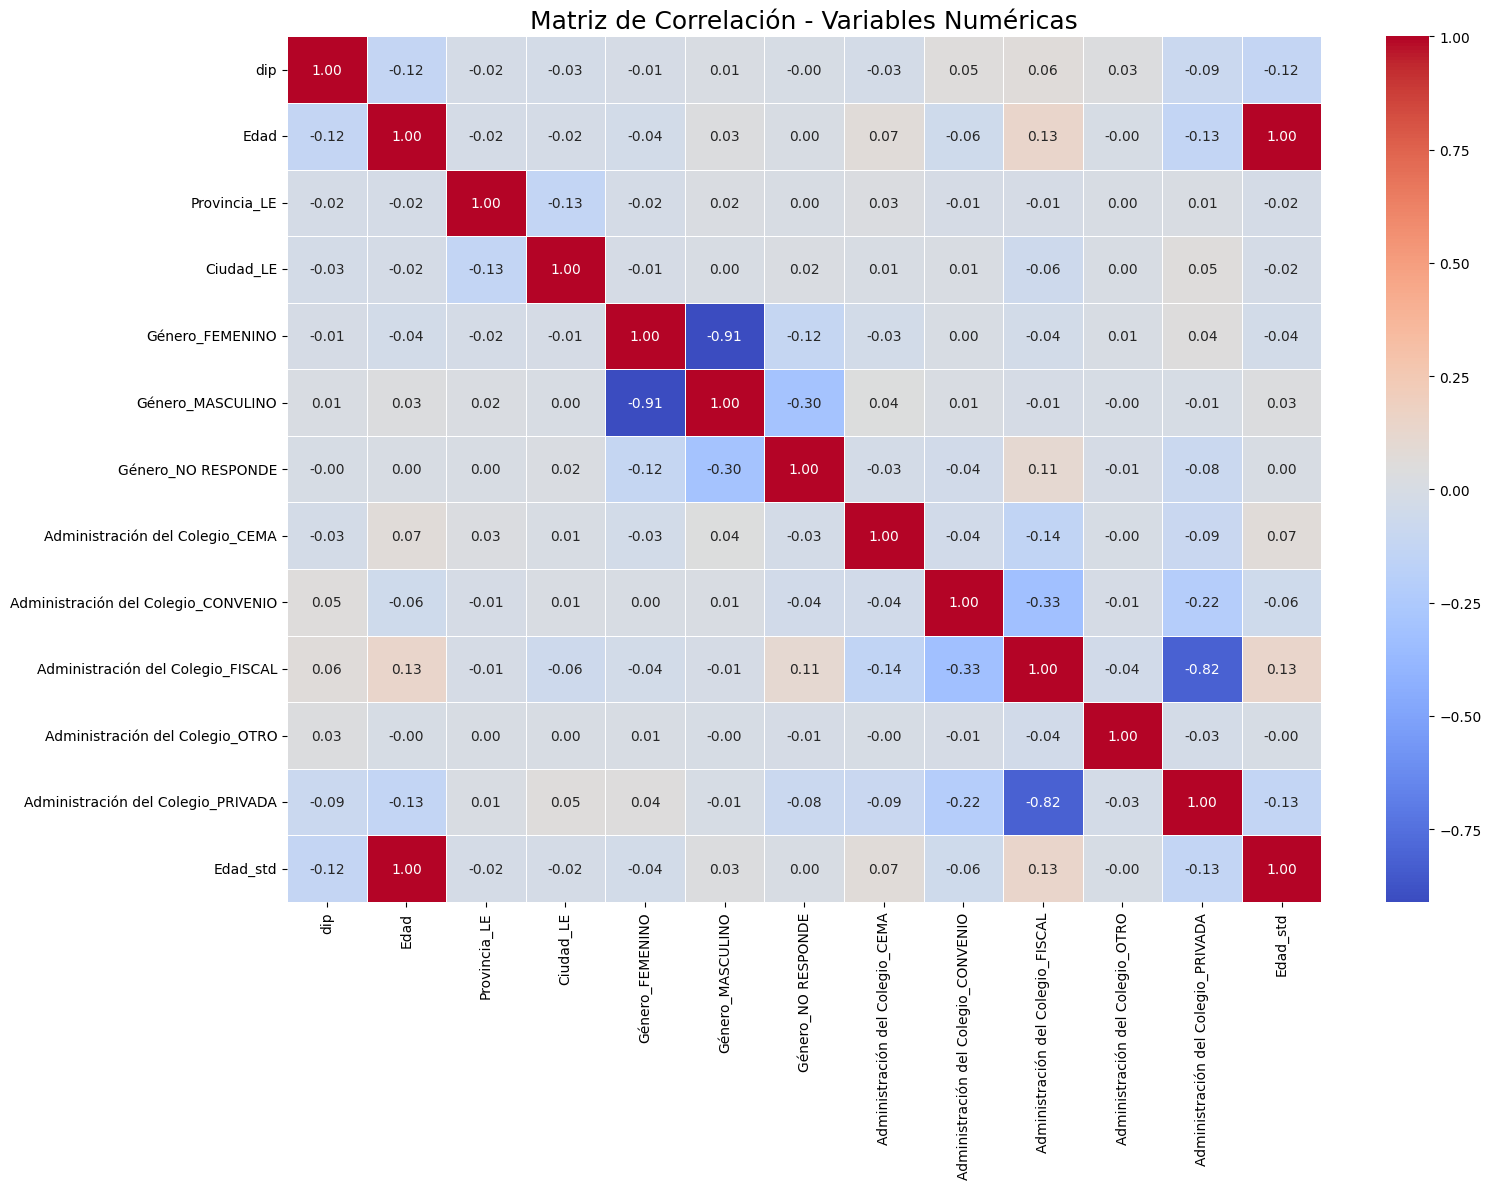

In [55]:
# ===============================================================
# 1. CREAR df_final (si ya lo tienes, puedes saltar esta parte)
# ===============================================================

df_final = pd.concat([
    df,                        # dataset original COMPLETO
    df_clean[['Provincia_LE', 'Ciudad_LE']],         # Label Encoding
    df_onehot,                 # One-Hot Encoding
    df_clean[['Edad_std']]              # Escalado
], axis=1)

print("df_final creado correctamente")
display(df_final.head())


# ===============================================================
# 2. SELECCIONAR SOLO COLUMNAS NUMÉRICAS
# ===============================================================

df_corr = df_final.select_dtypes(include=['int64', 'float64'])

print("Columnas numéricas incluidas en la correlación:")
print(df_corr.columns.tolist())


# ===============================================================
# 3. CALCULAR MATRIZ DE CORRELACIÓN
# ===============================================================

corr_matrix = df_corr.corr()
print("Matriz de correlación calculada:")
display(corr_matrix)


# ===============================================================
# 4. GRAFICAR HEATMAP DE CORRELACIÓN
# ===============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,          # muestra los valores
    fmt=".2f",           # decimales
    cmap="coolwarm",     # colores
    linewidths=.5
)

plt.title("Matriz de Correlación - Variables Numéricas", fontsize=18)
plt.tight_layout()
plt.show()


In [57]:
df_final.to_csv("data/modelos/datos_prepro_estudiantes.csv", index=False, encoding="utf-8")

